In [1]:

#импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 

from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [2]:
pd.set_option('Display.max_columns', None)
pd.set_option('Display.max_rows', None)

In [3]:
import oracledb
import pyodbc 
import time


import oracledb


connection = oracledb.connect(
    user = "USR_IBRAGIMOVASM",
    password = "mYJfvnul",
    dsn ="cprd-dwh-dbprim:1521/ODSPROD"
)

cursor = connection.cursor()

#ID_NOM_COL, OBJECT_GEO_LAT, OBJECT_GEO_LON, ID_EXP_MONTH, ID_EXP_YEAR,  ID_DATE_NO_COL, ID_DATE_OO_COL, EXPOSURE_TO_YEAR 

df = pd.read_sql_query('''select   *          
                        from DMS_DOG_LOSS_CLINIC_свод
                       ''', connection) 

C:\Temp\Sakinat.Ibragimova\34\ipykernel_6240\2246695865.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query('''select   *


In [4]:
df.shape

(797568, 77)

In [5]:
# 1. Найти все POLICY_NUMBER, у которых хотя бы раз встречается не-null GROUP
policy_with_group = df[df['GROUP (KOD SETI/LPU)'].notna()]['POLICY_NUMBER'].unique()

# 2. Создать условие: 
#    POLICY_NUMBER есть в списке policy_with_group И при этом 'GROUP (KOD SETI/LPU)' IS NULL
mask_to_remove = df['POLICY_NUMBER'].isin(policy_with_group) & df['GROUP (KOD SETI/LPU)'].isna()

# 3. Удаляем такие строки
df = df[~mask_to_remove].reset_index(drop=True)


In [6]:
unique_count = df['POLICY_NUMBER'].nunique()
print(f"Количество уникальных POLICY_NUMBER: {unique_count}")

Количество уникальных POLICY_NUMBER: 93858


In [276]:
#df=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\модель распределения потоков_new_2.xlsx')

In [ ]:
#df_spark=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\спарк_all_transl2.xlsx')

In [88]:
df.head(100)

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,AGREEMENT_ID,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_INN,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,CANCEL_DATE,Пол,F_GENDER,CHILD,RELATIVE,REGION,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,COST_YEAR_PROGRAM,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM
0,2494-Сеть1,Центромед,82AE005056012C8911EE63D04CEC8B5F,008БС4581005475,БАЗИС (ТВЕРСКАЯ ОБЛАСТЬ),008БС4581005475,6950005657,"ООО ""БАЗИС""",Ю,008БС4581005475-9,2023-10-09,2024-10-08 23:59:59,2023-10-09,2024-10-08 23:59:59,367,0,0,2,15,0.13,NaT,М,0,0,0,Тверская,0,1,0,0,Программа № 1: Взрослая Тверь,10850.0,1.0,Первичный,Тверская обл,Prochee,48,40-49,18-64,1.00,Строительство,Раздел F,0,4.4,541.0,0.19,NaN,0.00,0.00,0.00,1.0,ТВЕРСКАЯ,PROCHEE,Прямой договор СБС,800.0,1.0,67FE2FFA-09A5-5D7F-E053-596510AC686B,2.0,ECONOM,1.0,5793.0,2,Риск,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.00,0.00,0.00,0.00,3,2.0,0.50
1,2494-Сеть1,Центромед,82AE005056012C8911EE63D04CEC8B5F,008БС4581005475,БАЗИС (ТВЕРСКАЯ ОБЛАСТЬ),008БС4581005475,6950005657,"ООО ""БАЗИС""",Ю,008БС4581005475-6,2023-10-09,2024-10-08 23:59:59,2023-10-09,2024-10-08 23:59:59,367,0,0,2,15,0.13,NaT,Ж,1,0,0,Тверская,0,1,0,0,Программа № 1: Взрослая Тверь,10850.0,1.0,Первичный,Тверская обл,Prochee,51,50-59,18-64,1.00,Строительство,Раздел F,0,4.4,541.0,0.19,NaN,0.00,0.00,0.00,1.0,None,None,None,NaN,NaN,None,NaN,ECONOM,1.0,5793.0,2,Риск,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.00,0.00,0.00,0.00,3,2.0,0.50
2,845/Клиника Эксперт Тверь/69-744-01,Клиника Эксперт Тверь,82AE005056012C8911EE63D04CEC8B5F,008БС4581005475,БАЗИС (ТВЕРСКАЯ ОБЛАСТЬ),008БС4581005475,6950005657,"ООО ""БАЗИС""",Ю,008БС4581005475-7,2023-10-09,2024-10-08 23:59:59,2023-10-09,2024-10-08 23:59:59,367,0,0,2,15,0.13,NaT,М,0,0,0,None,0,1,0,0,Программа № 1: Взрослая Тверь,10850.0,1.0,Первичный,Тверская обл,Prochee,39,30-39,18-64,1.00,Строительство,Раздел F,0,4.6,420.0,0.12,NaN,0.00,0.00,0.00,1.0,None,None,None,NaN,NaN,None,NaN,Prochee,0.0,8433.0,1,Риск,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.00,0.00,0.00,0.00,3,2.0,0.50
3,2494-Сеть1,Центромед,82AE005056012C8911EE63D04CEC8B5F,008БС4581005475,БАЗИС (ТВЕРСКАЯ ОБЛАСТЬ),008БС4581005475,6950005657,"ООО ""БАЗИС""",Ю,008БС4581005475-3,2023-10-09,2024-10-08 23:59:59,2023-10-09,2024-10-08 23:59:59,367,0,0,2,15,0.13,NaT,М,0,0,0,Тверская,0,1,0,0,Программа № 1: Взрослая Тверь,10850.0,1.0,Первичный,Тверская обл,Prochee,29,18-29,18-64,1.00,Строительство,Раздел F,0,4.4,541.0,0.19,NaN,0.00,0.00,0.00,1.0,None,None,None,NaN,NaN,None,NaN,ECONOM,1.0,5793.0,2,Риск,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.00,0.00,0.00,0.00,3,2.0,0.50
4,845/Клиника Эксперт Тверь/69-744-01,Клиника Эксперт Тверь,82AE005056012C8911EE63D04CEC8B5F,008БС4581005475,БАЗИС (ТВЕРСКАЯ ОБЛАСТЬ),008БС4581005475,6950005657,"ООО ""БАЗИС""",Ю,008БС4581005475-5,2023-10-09,2024-10-08 23:59:59,2023-10-09,2024-10-08 23:59:59,367,0,0,2,15,0.13,NaT,М,0,0,0,Тверская,0,1,0,0,Программа № 1: Взрослая Тверь,10850.0,1.0,Первичный,Тверская обл,Prochee,31,30-39,18-64,1.00,Строительство,Раздел F,0,4.6,420.0,0.12,NaN,0.00,0.00,0.00,1.0,None,None,None,NaN,NaN,None,NaN,Prochee,0.

In [7]:
df = df.drop(columns=[
    'INSURANT_INN', 'WP_FULL', 'WP', 'ADDRESS', 'REGION', 'POLICY_ID', 'PROGRAM_ID',
    'COST_YEAR_PROGRAM', 'INSURED_FULLMONTH', 'INSURED_FULLYEAR', 'END_DATE_TRUE',
    'CANCEL_DATE', 'BIRTH_DATE', 'AGREEMENT_ID','INSURANT_TYPE', 'FIO', 'CNT_LPU_V_SETI_1'
], errors='ignore')

In [8]:
df['MAX_STAR'] = df['MAX_STAR'].fillna(-1)
df['MAX_REVIEWS'] = df['MAX_REVIEWS'].fillna(-1)
df['MIN_BUS_DIST_MIN'] = df['MIN_BUS_DIST_MIN'].fillna(-1)
df['MIN_SUBWAY_DIST_MIN'] = df['MIN_SUBWAY_DIST_MIN'].fillna(-1)
df['MAX_SUBWAY_SYNT'] = df['MAX_SUBWAY_SYNT'].fillna(-1)
df['AVG_SUBWAY_SYNT'] = df['AVG_SUBWAY_SYNT'].fillna(-1)
df['MIN_SUBWAY_SYNT'] = df['MIN_SUBWAY_SYNT'].fillna(-1)
df['SUM_PRICE_TO_PAY'] = df['SUM_PRICE_TO_PAY'].fillna(0)
df['CNT'] = df['CNT'].fillna(0)
df['CLINIC_RANK'] = df['CLINIC_RANK'].fillna(0)
df['PROGRAM_LIST_RISK_PREPAY_SPEC'] = df['PROGRAM_LIST_RISK_PREPAY_SPEC'].fillna(-1)
df['SHARE_LPU_IN_PROGRAM'] = df['SHARE_LPU_IN_PROGRAM'].fillna(-1)



In [9]:
df['COMISSION_PERCENTAGE_FIX'] = df['COMISSION_PERCENTAGE_FIX'].fillna('not_def')
df['ASSISTANCE_TYPE'] = df['ASSISTANCE_TYPE'].fillna('not_def')
df['PROLONGATION_TYPE'] = df['PROLONGATION_TYPE'].fillna('not_def')
df['COVENANTA'] = df['COVENANTA'].fillna('not_def')

In [10]:
df['HOLDING'] = df['HOLDING'].fillna(df['INSURANT_NAME'])

In [108]:
df.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Пол,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM
0,2494-Сеть1,Центромед,008БС4581005475,БАЗИС (ТВЕРСКАЯ ОБЛАСТЬ),008БС4581005475,"ООО ""БАЗИС""",008БС4581005475-9,2023-10-09,2024-10-08 23:59:59,2023-10-09,2024-10-08 23:59:59,367,0,0,2,15,0.13,М,0,0,0,0,1,0,0,Программа № 1: Взрослая Тверь,1.0,Первичный,Тверская обл,Prochee,48,40-49,18-64,1.0,Строительство,Раздел F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,ТВЕРСКАЯ,PROCHEE,Прямой договор СБС,800.0,1.0,67FE2FFA-09A5-5D7F-E053-596510AC686B,2.0,ECONOM,1.0,5793.0,2,Риск,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5
1,2494-Сеть1,Центромед,008БС4581005475,БАЗИС (ТВЕРСКАЯ ОБЛАСТЬ),008БС4581005475,"ООО ""БАЗИС""",008БС4581005475-6,2023-10-09,2024-10-08 23:59:59,2023-10-09,2024-10-08 23:59:59,367,0,0,2,15,0.13,Ж,1,0,0,0,1,0,0,Программа № 1: Взрослая Тверь,1.0,Первичный,Тверская обл,Prochee,51,50-59,18-64,1.0,Строительство,Раздел F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Риск,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5
2,845/Клиника Эксперт Тверь/69-744-01,Клиника Эксперт Тверь,008БС4581005475,БАЗИС (ТВЕРСКАЯ ОБЛАСТЬ),008БС4581005475,"ООО ""БАЗИС""",008БС4581005475-7,2023-10-09,2024-10-08 23:59:59,2023-10-09,2024-10-08 23:59:59,367,0,0,2,15,0.13,М,0,0,0,0,1,0,0,Программа № 1: Взрослая Тверь,1.0,Первичный,Тверская обл,Prochee,39,30-39,18-64,1.0,Строительство,Раздел F,0,4.6,420.0,0.12,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Риск,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2.0,0.5
3,2494-Сеть1,Центромед,008БС4581005475,БАЗИС (ТВЕРСКАЯ ОБЛАСТЬ),008БС4581005475,"ООО ""БАЗИС""",008БС4581005475-3,2023-10-09,2024-10-08 23:59:59,2023-10-09,2024-10-08 23:59:59,367,0,0,2,15,0.13,М,0,0,0,0,1,0,0,Программа № 1: Взрослая Тверь,1.0,Первичный,Тверская обл,Prochee,29,18-29,18-64,1.0,Строительство,Раздел F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Риск,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5
4,845/Клиника Эксперт Тверь/69-744-01,Клиника Эксперт Тверь,008БС4581005475,БАЗИС (ТВЕРСКАЯ ОБЛАСТЬ),008БС4581005475,"ООО ""БАЗИС""",008БС4581005475-5,2023-10-09,2024-10-08 23:59:59,2023-10-09,2024-10-08 23:59:59,367,0,0,2,15,0.13,М,0,0,0,0,1,0,0,Программа № 1: Взрослая Тверь,1.0,Первичный,Тверская обл,Prochee,31,30-39,18-64,1.0,Строительство,Раздел F,0,4.6,420.0,0.12,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Риск,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2.0,0.5


In [11]:
df.shape

(728796, 71)

In [12]:
df.isna().sum()

GROUP (KOD SETI/LPU)               15771
GROUP_NAME_SETI_TOU                42269
DOGOVOR_NUMBER_POLICY                  0
HOLDING                                0
HOLDING_DOC_NUM                   129463
INSURANT_NAME                          0
POLICY_NUMBER                          0
RESP_DT_BEG                            0
RESP_DT_END                            0
START_DATE                             0
END_DATE                               0
DAYS                                   0
ATTACHMENT                             0
UNPINNING                              0
CNT_PROGRAM                            0
CNT_POLICY_BEG                         0
CNT_PROGRAM/cnt_policy_beg             0
Пол                                    0
F_GENDER                               0
CHILD                                  0
RELATIVE                               0
PREPAYMENT                             0
DIRECT_SERVICE                         0
COMPENSATION                           0
VIP             

In [ ]:
# df['INSURANT_INN'] = df['INSURANT_INN'].astype(str).str.strip()
# df_spark['INSURANT_INN'] = df_spark['INSURANT_INN'].astype(str).str.strip()


In [ ]:
# # Шаг 1: Убедимся, что RESP_DT_BEG — тип datetime
# df['RESP_DT_BEG'] = pd.to_datetime(df['RESP_DT_BEG'])
# df['YEAR'] = df['RESP_DT_BEG'].dt.year  # создаём год для джойна

# # Шаг 2: Добавляем префикс spark_ ко ВСЕМ столбцам df_spark, кроме INN и YEAR (ключей)
# # Сохраним оригинальные названия ключей
# df_spark_renamed = df_spark.copy()

# # Список столбцов, которые НЕ нужно переименовывать (ключи)
# key_columns = ['INSURANT_INN', 'INN', 'YEAR']  # если INN есть — он будет заменён на INSURANT_INN

# # Переименовываем все остальные столбцы: добавляем spark_
# rename_cols = {
#     col: f"spark_{col}" for col in df_spark_renamed.columns if col not in key_columns
# }
# df_spark_renamed = df_spark_renamed.rename(columns=rename_cols)

# # Если в df_spark был INN — переименуем его в INSURANT_INN для совпадения с df
# if 'INN' in df_spark_renamed.columns:
#     df_spark_renamed = df_spark_renamed.rename(columns={'INN': 'INSURANT_INN'})

# # Шаг 3: Объединяем по двум ключам
# df_merge = pd.merge(
#     df,
#     df_spark_renamed,
#     on=['INSURANT_INN', 'YEAR'],
#     how='left'
# )

# # Шаг 4: Удаляем временный столбец YEAR, если он не нужен
# df_merge = df_merge.drop(columns=['YEAR'], errors='ignore')  # errors='ignore' — безопасно




C:\Temp\Sakinat.Ibragimova\6\ipykernel_8248\2499404885.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['RESP_DT_BEG'] = pd.to_datetime(df['RESP_DT_BEG'])


In [ ]:
#df_merge.head(100)

,GROUP (KOD SETI/LPU),AGREEMENT_ID,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_INN,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,CANCEL_DATE,POLICY_STATUS,BIRTH_DATE,Пол,F_GENDER,CHILD,RELATIVE,FIO,WP_FULL,WP,REGION,ADDRESS,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,OMO_TYPE,PROGRAM_ID,POLICY_ID,PROGRAM_NAME,COST_YEAR_PROGRAM,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,END_DATE_TRUE,INSURED_FULLMONTH,INSURED_FULLYEAR,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,Регион_итог,MAX_STAR,MAX_REVIEWS,MAX_BUS_DIST_MIN,MAX_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,GROUP name SETI/TOU,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_STAR,SHARE_REVIEW,SHARE_BUS_DIST_MIN,SHARE_SUBWAY_DIST_MIN,SHARE_SUBWAY_SYNT,spark_name,spark_website,spark_date_reg,spark_age_of_company,spark_liquidation,spark_form_of_ownership,spark_public_sector,spark_IDO,spark_IFR,spark_IPD,spark_Zalog,spark_Leasing,spark_Intellect_property,spark_Size_of_company,spark_count_empoyees,spark_Equity_capital,spark_Tax_type,spark_income,spark_outcome,spark_income_tax,spark_Vznos_PFR,spark_Vznos_FOMS,spark_Vznos_FSS,spark_Net_assets,spark_Current_assets,spark_UK,spark_Nerasped_profit,spark_sobstvnii_oborotnii_capital,spark_Revenue,spark_Profit_before_tax,spark_Net_profit,spark_Salary,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv,spark_Sootnoshenie sovokupnogo dolga k EBIT,spark_Rentabelnost prodazh,spark_Rentabelnost activov (ROA),spark_Rentabelnost capitala (ROE),spark_Coeff tekushei liqvidnosti,spark_Coeff bistroi liqvidnosti
0,2502-Сеть1,9DBD0050560A780711F0C6132BDA883B,008БС4581012214,"ООО ""ВЕКТОР""",NaN,9725091548,"ООО ""ВЕКТОР""",Ю,008БС4581012214-8,2025-11-21,20.11.26,21.11.25,20.11.26,366,0,0,5,10,0.50,NaN,1,18.04.88,Ж,1,0,0,ЦАРЕВСКАЯ ЭЛЬВИРА МУНИРОВНА,0.0,0,NaN,"Казань, ул. Меридианная, дом 3, корп. А кв. 74",0,1,0,1,4.2,СБС1056,7404864,Программа № 4: Взрослая Казань,25970.0,1.0,NaN,г Москва,Москва,37,30-39,18-64,20.11.26,12,1,0.03,Деятельность в области информации и связи,Раздел J,ТАТАРСТАН,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Здоровье семьи,ТАТАРСТАН,PROCHEE,Прямой договор СБС,4750.00,3.0,1.0,BUSINESS,3.0,NaN,NaN,NaN,1,-1.000,-1.000,-1.000,-1.000,-1.000,"ВЕКТОР, ООО",0.0,2022-08-03,3.0,0.0,16 - Частная собственность,NaN,4.0,26.0,NaN,NaN,NaN,NaN,Микропредприятия,7.0,240000.0,АУСН,1.667800e+07,4.481400e+07,NaN,5058260.0,NaN,NaN,6073000.0,1.541000e+07,NaN,NaN,5.818000e+06,1.524000e+07,-28136000.0,-28750000.0,NaN,1.6,0.0,-1.7,-0.9,-1.4,1.6,1.6
1,2502-Сеть1,9DBD0050560A780711F0C6132BDA883B,008БС4581012214,"ООО ""ВЕКТОР""",NaN,9725091548,"ООО ""ВЕКТОР""",Ю,008БС4581012214-7,2025-11-21,20.11.26,21.11.25,20.11.26,366,0,0,5,10,0.50,NaN,1,23.01.85,М,0,0,0,ЖУРАВЛЕВ АНДРЕЙ ЮРЬЕВИЧ,0.0,0,NaN,"Казань, ул. Меридианная, дом 3, корп. А кв. 74",0,1,0,1,4.2,СБС1056,7404863,Программа № 4: Взрослая Казань,25970.0,1.0,NaN,г Москва,Москва,40,40-49,18-64,20.11.26,12,1,0.03,Деятельность в области информации и связи,Раздел J,ТАТАРСТАН,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Здоровье семьи,ТАТАРСТАН,PROCHEE,NaN,NaN,NaN,NaN,BUSINESS,3.0,NaN,NaN,NaN,0,-1.000,-1.000,-1.000,-1.000,-1.000,"ВЕКТОР, ООО",0.0,2022-08-03,3.0,0.0,16 - Частная собственность,NaN,4.0,26.0,NaN,NaN,NaN,NaN,Микропредприятия,7.0,240000.0,АУСН,1.667800e+07,4.481400e+07,NaN,5058260.0,NaN,NaN,6073000.0,1.541000e+07,NaN,NaN,5.818000e+06,1.524000e+07,-28136000.0,-28750000.0,NaN,1.6,0.0,-1.7,-0.9,-1.4,1.6,1.6
2,RMS001500,824A005056012C8911EDA84DEB1E73D5,008БС4581002442,ЦЕНТР СНАБЖЕНИЯ,008БС4581002442,5907020294,"ООО ""ЦЕНТР СНАБЖЕНИЯ""",Ю,008БС4581002442-1,2023-02-20,19.02.24,20.02.23,19.02.24,366,0,0,1,1,1.00,NaN,1,05.12.02,Ж,1,0,0,Юрлова Людмила Руслановна,42810.0,0,Пермский,"614030 Пермский край

In [14]:
df_merge=df

In [ ]:
#df_merge.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\рез-т запроса полисы убытки_спарк.xlsx', index=False)

In [15]:
df_merge=df_merge[df_merge['CNT_POLICY_BEG']>0]
df_merge=df_merge[df_merge['CNT_POLICY_BEG']<500]
df_merge=df_merge[df_merge['HOLDING']!='ЕДИНАЯ РОССИЯ']
df_merge=df_merge[df_merge['INSURED_EXP_NEW']>0]
df_merge=df_merge[df_merge['DOGOVOR_NUMBER_POLICY']!='008BS4580005015']

In [16]:
df_merge.shape

(717744, 71)

In [17]:
unique_count = df_merge['POLICY_NUMBER'].nunique()
print(f"Количество уникальных значений в 'POLICY_NUMBER': {unique_count}")


Количество уникальных значений в 'POLICY_NUMBER': 93324


In [18]:
df_merge.columns

Index(['GROUP (KOD SETI/LPU)', 'GROUP_NAME_SETI_TOU', 'DOGOVOR_NUMBER_POLICY',
       'HOLDING', 'HOLDING_DOC_NUM', 'INSURANT_NAME', 'POLICY_NUMBER',
       'RESP_DT_BEG', 'RESP_DT_END', 'START_DATE', 'END_DATE', 'DAYS',
       'ATTACHMENT', 'UNPINNING', 'CNT_PROGRAM', 'CNT_POLICY_BEG',
       'CNT_PROGRAM/cnt_policy_beg', 'Пол', 'F_GENDER', 'CHILD', 'RELATIVE',
       'PREPAYMENT', 'DIRECT_SERVICE', 'COMPENSATION', 'VIP', 'PROGRAM_NAME',
       'DOGOVOR_TYPE', 'PROLONGATION_TYPE', 'INSURANT_REGION',
       'INSURANT_REGION_GROUP', 'INS_AGE', 'INS_AGE_CATEGORY',
       'INSURED_AGEGROUP', 'INSURED_EXP_NEW', 'OKVED_GROUP', 'OKVED_RAZDEL',
       'COVENANTA_ZHUD', 'MAX_STAR', 'MAX_REVIEWS', 'MIN_BUS_DIST_MIN',
       'MIN_SUBWAY_DIST_MIN', 'MAX_SUBWAY_SYNT', 'MIN_SUBWAY_SYNT',
       'AVG_SUBWAY_SYNT', 'CNT_LPU_V_SETI', 'REGION ITOG', 'REGION ITOG_GROUP',
       'ASSISTANCE_TYPE', 'SUM_PRICE_TO_PAY', 'CNT', 'SERVICE_POINT_ID_NEW',
       'CLINIC_RANK', 'PRICE_LEVEL', 'PRICE_LEVEL_NUM', '

In [19]:
import translit
from  transliterate import translit

col_list=df_merge.columns.to_list ()
for col in  col_list:
    df_merge.rename(columns={col: translit(col, 'ru', reversed=True)}, inplace=True)

In [20]:
def make_col (x): 
    return translit(str(x), 'ru', reversed=True)

In [21]:
for col in df_merge.select_dtypes(exclude=['float', 'number']).columns.to_list():

    try:
        df_merge[col]=df_merge[col].apply(make_col)
    except BaseException: 
        print (col, df_merge.dtypes[col])

In [23]:
fold_df=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df_1.xlsx')

In [24]:
# Проверка наличия столбцов
if 'HOLDING' not in df_merge.columns:
    print("❌ В df нет столбца HOLDING")
elif 'HOLDING' not in fold_df.columns:
    print("❌ В fold_df нет столбца HOLDING")
elif 'FOLD' not in fold_df.columns:
    print("❌ В fold_df нет столбца FOLD")
else:
    # Убедимся, что в fold_df нет дубликатов по HOLDING
    fold_lookup = fold_df[['HOLDING', 'FOLD']].drop_duplicates(subset='HOLDING').copy()

    # Выполняем left join к df
    fold_df_1 = df_merge.merge(fold_lookup, on='HOLDING', how='left')
    fold_df_1['FOLD'] = fold_df_1['FOLD'].fillna(5).astype(int)

    print(f"✅ Поле FOLD успешно добавлено. Количество строк в df: {len(df)} (не изменилось)")

✅ Поле FOLD успешно добавлено. Количество строк в df: 728796 (не изменилось)


In [25]:
fold_df_1.head(100)

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.00,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.00,0.00,0.00,0.00,1.0,TVERSKAJa,PROCHEE,Prjamoj dogovor SBS,800.0,1.0,67FE2FFA-09A5-5D7F-E053-596510AC686B,2.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.00,0.00,0.00,0.00,3,2.0,0.50,1
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,Zh,1,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,51,50-59,18-64,1.00,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.00,0.00,0.00,0.00,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.00,0.00,0.00,0.00,3,2.0,0.50,1
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,39,30-39,18-64,1.00,Stroitel'stvo,Razdel F,0,4.6,420.0,0.12,-1.00,0.00,0.00,0.00,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.00,0.00,0.00,0.00,3,2.0,0.50,1
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-3,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,29,18-29,18-64,1.00,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.00,0.00,0.00,0.00,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.00,0.00,0.00,0.00,3,2.0,0.50,1
4,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-5,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,31,30-39,18-64,1.00,Stroitel'stvo,Razdel F,0,4.6,420.0,0.12,-1.00,0.00,0.00,0.00,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.00,0.00,0.00,0.00,3,2.0,0.50,1
5,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-4,2023-10-09 00:00

In [293]:
# new_df = df_merge.groupby('HOLDING')['PAID_FLAG'].sum().reset_index()
# folds = new_df.sort_values(by='PAID_FLAG', ascending=False)
# folds['FOLD'] = [i % 5 + 1 for i in range(len(folds))]
# print(folds.groupby('FOLD')['PAID_FLAG'].sum())
# folds

In [294]:
# fold_df = pd.merge(df_merge, folds[['HOLDING', 'FOLD']], how='left', on='HOLDING')

In [26]:
print(fold_df_1.groupby('FOLD')['DOGOVOR_NUMBER_POLICY'].count())

FOLD
1    239269
2    109252
3    123734
4    146365
5     99124
Name: DOGOVOR_NUMBER_POLICY, dtype: int64


In [27]:
print(fold_df_1.groupby('FOLD')['HOLDING'].count())

FOLD
1    239269
2    109252
3    123734
4    146365
5     99124
Name: HOLDING, dtype: int64


In [28]:
fold_df_1.columns.tolist()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'COVENANTA_ZHUD',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGR

In [29]:
# Только в строковых столбцах
for col in fold_df_1.select_dtypes(include='object').columns:
    fold_df_1[col] = fold_df_1[col].astype(str).str.replace(';', ',', regex=False)


In [30]:
fold_df_1.columns.to_list()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'COVENANTA_ZHUD',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGR

In [ ]:
# fold_df=fold_df.drop([ 'AGREEMENT_ID',
#  'HOLDING_DOC_NUM',
#  'INSURANT_INN',
#  'CANCEL_DATE',
#  'POLICY_STATUS',
#  'BIRTH_DATE',
#  'Pol',
#  'CHILD',
#  'FIO',
#  'WP_FULL',
#  'WP',
#  'ADDRESS',
#  'PREPAYMENT',
#  'OMO_TYPE',
#  'PROGRAM_ID',
#  'POLICY_ID',
#  'COST_YEAR_PROGRAM',
#  'DOGOVOR_TYPE',
#  'END_DATE_TRUE',
#  'INSURED_FULLMONTH',
#  'INSURED_FULLYEAR',
#  'POLICY_AGREEMENT_ID',
#  'POLICY_DOGOVOR_NUMBER_POLICY',
#  'POLICY_POLICY_NUMBER',
#  'NAME',
#  'COORDS',
#  'LOSS_BILL_POLICY_NUMBER',
#  'GROUP (KOD SETI/LPU)',
#  'GROUP name SETI/TOU',
#  'CODE TOU new',
#  'SERVICE_POINT_ID_NEW',
#  'spark_name',
#  'spark_date_reg'
#  ], axis=1)

In [ ]:
#fold_df.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df.xlsx')

In [ ]:
# fold_df.to_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df_2.csv', 
#                index=False, 
#                encoding='utf-8', 
#                sep=';')


In [ ]:
# # Шаг 1: Заменяем \u2010 на обычный дефис
# for col in fold_df.select_dtypes(include='object').columns:
#     fold_df[col] = fold_df[col].astype(str).str.replace('\u2010', '-', regex=False)

# for col in fold_df.select_dtypes(include='object').columns:
#     fold_df[col] = fold_df[col].astype(str).str.replace('\u200b', '-', regex=False)

# for col in fold_df.select_dtypes(include='object').columns:
#     fold_df[col] = fold_df[col].astype(str).str.replace('\u0306', '-', regex=False)
# # # Шаг 2: Сохраняем с безопасной кодировкой
# # fold_df.to_csv(
# #     r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df_2.csv',
# #     index=False,
# #     sep=';',
# #     encoding='utf-8-sig'
# # )


In [ ]:
# import unicodedata

# def remove_accents(text):
#     if isinstance(text, str):
#         # Нормализуем строку (разделяем буквы и знаки)
#         nfkd = unicodedata.normalize('NFKD', text)
#         # Оставляем только базовые символы
#         return ''.join(c for c in nfkd if not unicodedata.combining(c))
#     return text

# # Применяем ко всем строковым столбцам
# for col in fold_df.select_dtypes(include='object').columns:
#     fold_df[col] = fold_df[col].apply(remove_accents)


In [ ]:
# for col in fold_df.select_dtypes(include='object').columns:
#     fold_df[col] = fold_df[col].str.replace(';', ' ', regex=False)

In [55]:
# df = df.drop(columns=[
#     'RESP_DT_BEG', 'RESP_DT_END', 'START_DATE', 'END_DATE'
# ], errors='ignore')


In [31]:
import pandas as pd
import numpy as np

# Пример данных (если у вас уже есть fold_df — пропустите)
# fold_df['SHARE_SUBWAY_DIST_MIN_FROM_MIN'] = ...

# Создаём копию для безопасной обработки
col = fold_df_1['SHARE_SUBWAY_DIST_MIN_FROM_MIN'].copy()

# Разделяем -1 и остальные значения
bins_col = pd.cut(
    col, 
    bins=np.arange(0.0, col.max() + 0.11, 0.1),  # [0.0, 0.1, ..., max+0.1]
    include_lowest=True,  # включаем левую границу
    right=False,          # полуоткрытый интервал [x, x+0.1)
    precision=1
)

# Объединяем: -1 как отдельный уровень, остальное — по бинам
fold_df_1['SHARE_SUBWAY_DIST_MIN_BINS'] = np.where(
    col == -1,
    '-1',
    bins_col.astype(str).replace('nan', 'missing')  # на всякий случай
)

# Заменяем NaN (если были) на метку
fold_df_1['SHARE_SUBWAY_DIST_MIN_BINS'] = fold_df_1['SHARE_SUBWAY_DIST_MIN_BINS'].fillna('missing')


In [ ]:
# fold_df_1.to_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\model_5.csv',
#                index=False,
#                sep=';',
#                encoding='cp1251')


In [32]:
fold_df_1.shape

(717744, 73)

In [33]:
fold_df_1[fold_df_1['DOGOVOR_NUMBER_POLICY']=='008BS4580005015'].shape

(425, 73)

In [34]:
# Удаление строк, где DOGOVOR_NUMBER_POLICY == '008BS4580005015'
fold_df_1 = fold_df_1[fold_df_1['DOGOVOR_NUMBER_POLICY'] != '008BS4580005015'].copy()

# Проверка: количество удалённых строк
print(f"Осталось строк: {fold_df_1.shape[0]}")

Осталось строк: 717319


In [35]:
fold_df_1.to_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\model_3.csv', index=False, sep=';', encoding='cp1251')

# Построение модели

In [126]:
#импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 

from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [7]:
df=pd.read_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\model_3.csv',
               sep=';',
               encoding='cp1251')

C:\Temp\Sakinat.Ibragimova\34\ipykernel_12584\1337247655.py:1: DtypeWarning: Columns (57,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\model_3.csv',


In [88]:
# df=pd.read_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\model_3.csv',
#                sep=';',
#                encoding='cp1251')

In [36]:
df=fold_df_1

In [37]:
df.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.0,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,TVERSKAJa,PROCHEE,Prjamoj dogovor SBS,800.0,1.0,67FE2FFA-09A5-5D7F-E053-596510AC686B,2.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,Zh,1,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,51,50-59,18-64,1.0,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,39,30-39,18-64,1.0,Stroitel'stvo,Razdel F,0,4.6,420.0,0.12,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-3,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,29,18-29,18-64,1.0,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1
4,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-5,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,31,30-39,18-64,1.0,Stroitel'stvo,Razdel F,0,4.6,420.0,0.12,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1


In [38]:
df.shape

(717319, 73)

In [39]:
df['PAID_FLAG_1'] = df['CLINIC_RANK'].apply(lambda x: 1 if x == 1 else 0)

C:\Temp\Sakinat.Ibragimova\21\ipykernel_2476\2937114705.py:1: DtypeWarning: Columns (57,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\model_3.csv',


In [40]:
# Фильтрация: оставляем только строки, где PAID_FLAG_1 == 1
# Затем берём уникальные значения POLICY_NUMBER
unique_policies_paid = df[df['PAID_FLAG_1'] == 1]['POLICY_NUMBER'].dropna().unique()

# Создаём DataFrame (таблицу)
unique_policies_paid = pd.DataFrame({'POLICY_NUMBER': unique_policies_paid})

# Опционально: сортировка
unique_policies_paid = unique_policies_paid.sort_values('POLICY_NUMBER').reset_index(drop=True)



In [41]:
unique_policies_paid.shape

(36251, 1)

In [42]:
df.shape

(717319, 74)

In [43]:
df[df['POLICY_NUMBER']=='008DT4580000044-402']


,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1
80381,800/MTs Doktor Pljus/18-604-01,MTs Doktor Pljus,008DT4580000044,IGS,008DT4580000042,"OOO ""NEU""",008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:59:59,316,1,0,5,482,0.01,M,0,0,0,0,1,0,0,Regiony2,1.0,Pervichnyj,Jamalo-Nenetskij AO,Prochee,40,40-49,18-64,1.87,Dobycha poleznyh iskopaemyh,Razdel B,0,4.8,1032.0,0.17,-1.00,0.00,0.00,0.00,1.0,None,None,not_def,0.0,0.0,None,0.0,BUSINESS,3.0,11365.0,21,Risk,0.0,noncovenant,0,0.63,0.96,0.14,0.16,-1.00,0.00,0.00,0.00,3,74.0,0.01,1,-1,0
81485,RMS015559,Meditsinskij tsentr A2Med,008DT4580000044,IGS,008DT4580000042,"OOO ""NEU""",008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:59:59,316,1,0,5,482,0.01,M,0,0,0,0,1,0,0,Regiony2,1.0,Pervichnyj,Jamalo-Nenetskij AO,Prochee,40,40-49,18-64,1.87,Dobycha poleznyh iskopaemyh,Razdel B,0,4.7,287.0,0.15,1.03,0.31,0.31,0.31,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,NaN,-1,Risk,0.0,noncovenant,0,-1.00,0.94,0.04,0.14,0.51,0.31,0.31,0.31,3,74.0,0.01,1,"[0.5, 0.6)",0
82633,RMS004196,"OOO ""LDTs""",008DT4580000044,IGS,008DT4580000042,"OOO ""NEU""",008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:59:59,316,1,0,5,482,0.01,M,0,0,0,0,1,0,0,Regiony2,1.0,Pervichnyj,Jamalo-Nenetskij AO,Prochee,40,40-49,18-64,1.87,Dobycha poleznyh iskopaemyh,Razdel B,0,-1.0,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,1.0,None,None,not_def,0.0,0.0,None,0.0,STANDART,2.0,12312.0,13,Risk,0.0,noncovenant,0,0.68,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,3,74.0,0.01,1,-1,0
83369,RMS006320,"OOO ""STs - Nil' i K ""Sterlitamakskij"" (Hudajbe...",008DT4580000044,IGS,008DT4580000042,"OOO ""NEU""",008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:59:59,316,1,0,5,482,0.01,M,0,0,0,0,1,0,0,Regiony2,1.0,Pervichnyj,Jamalo-Nenetskij AO,Prochee,40,40-49,18-64,1.87,Dobycha poleznyh iskopaemyh,Razdel B,0,-1.0,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,NaN,-1,Risk,0.0,noncovenant,0,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,3,74.0,0.01,1,-1,0
84563,4976-Set'1371,KB № 119 FMBA Rossii,008DT4580000044,IGS,008DT4580000042,"OOO ""NEU""",008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:59:59,316,1,0,5,482,0.01,M,0,0,0,0,1,0,0,Regiony2,1.0,Pervichnyj,Jamalo-Nenetskij AO,Prochee,40,40-49,18-64,1.87,Dobycha poleznyh iskopaemyh,Razdel B,0,-1.0,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,2.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,NaN,-1,Risk,0.0,noncovenant,0,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,3,74.0,0.03,1,-1,0
84951,4976-Set'1897,JuniMed (Tjumen'),008DT4580000044,IGS,008DT4580000042,"OOO ""NEU""",008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:

In [44]:
df.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.0,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,TVERSKAJa,PROCHEE,Prjamoj dogovor SBS,800.0,1.0,67FE2FFA-09A5-5D7F-E053-596510AC686B,2.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,Zh,1,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,51,50-59,18-64,1.0,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,39,30-39,18-64,1.0,Stroitel'stvo,Razdel F,0,4.6,420.0,0.12,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-3,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,29,18-29,18-64,1.0,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0
4,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-5,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,31,30-39,18-64,1.0,Stroitel'stvo,Razdel F,0,4.6,420.0,0.12,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0


In [45]:
df = df.fillna({
    col: -1 for col in df.select_dtypes(include='number').columns
})

In [ ]:
# fold_df=pd.read_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df_4.csv',
#                sep=';',
#                encoding='cp1251')

C:\Temp\Sakinat.Ibragimova\53\ipykernel_10516\3343980095.py:1: DtypeWarning: Columns (30,36,37,38,43) have mixed types. Specify dtype option on import or set low_memory=False.
  fold_df=pd.read_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df_4.csv',


In [ ]:
# df.rename(columns={'FOLD': 'FOLD_old'}, inplace=True)

In [ ]:
# # Проверка наличия столбцов
# if 'HOLDING' not in df.columns:
#     print("❌ В df нет столбца HOLDING")
# elif 'HOLDING' not in fold_df.columns:
#     print("❌ В fold_df нет столбца HOLDING")
# elif 'FOLD' not in fold_df.columns:
#     print("❌ В fold_df нет столбца FOLD")
# else:
#     # Убедимся, что в fold_df нет дубликатов по HOLDING
#     fold_lookup = fold_df[['HOLDING', 'FOLD']].drop_duplicates(subset='HOLDING').copy()

#     # Выполняем left join к df
#     df = df.merge(fold_lookup, on='HOLDING', how='left')
#     df['FOLD'] = df['FOLD'].fillna(5).astype(int)

#     print(f"✅ Поле FOLD успешно добавлено. Количество строк в df: {len(df)} (не изменилось)")


✅ Поле FOLD успешно добавлено. Количество строк в df: 514744 (не изменилось)


In [46]:
print(df.groupby('FOLD')['HOLDING'].count())

FOLD
1    239269
2    109252
3    123734
4    146365
5     98699
Name: HOLDING, dtype: int64


In [47]:
df.isna().sum()

GROUP (KOD SETI/LPU)              0
GROUP_NAME_SETI_TOU               0
DOGOVOR_NUMBER_POLICY             0
HOLDING                           0
HOLDING_DOC_NUM                   0
INSURANT_NAME                     0
POLICY_NUMBER                     0
RESP_DT_BEG                       0
RESP_DT_END                       0
START_DATE                        0
END_DATE                          0
DAYS                              0
ATTACHMENT                        0
UNPINNING                         0
CNT_PROGRAM                       0
CNT_POLICY_BEG                    0
CNT_PROGRAM/cnt_policy_beg        0
Pol                               0
F_GENDER                          0
CHILD                             0
RELATIVE                          0
PREPAYMENT                        0
DIRECT_SERVICE                    0
COMPENSATION                      0
VIP                               0
PROGRAM_NAME                      0
DOGOVOR_TYPE                      0
PROLONGATION_TYPE           

In [48]:
df.columns.tolist()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'COVENANTA_ZHUD',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGR

In [49]:
df['const']=1

In [50]:
def create_variate(a):
    if a == -1:
        return 0
    if a>=0 and a <= 0.14:
        return a
    else:
        return 0.14

# Применяем функцию к столбцу 
df['0-0.14_SHARE_LPU_IN_PROGRAM'] = df['SHARE_LPU_IN_PROGRAM'].apply(create_variate)

In [51]:
def create_variate(a):
    if a > 0.14:
        return a
    else:
        return 0.14

# Применяем функцию к столбцу 
df['>0.14_SHARE_LPU_IN_PROGRAM'] = df['SHARE_LPU_IN_PROGRAM'].apply(create_variate)

In [52]:
def create_variate(a):
    if a < 1:
        return a
    else:
        return 1

# Применяем функцию к столбцу 
df['SHARE_STAR_FROM_MAX_v'] = df['SHARE_STAR_FROM_MAX'].apply(create_variate)

In [53]:
df['SHARE_PRICE_LPU_BIN'] = np.where(
    df['SHARE_PRICE_LPU_FROM_MAX'] == -1,
    'level_1 (-1)',
    np.where(df['SHARE_PRICE_LPU_FROM_MAX'].isna(), 'missing',
             'level_2 (others)')
)


In [54]:
df['SHARE_STAR_FROM_MAX_BIN'] = np.where(
    df['SHARE_STAR_FROM_MAX'] == -1,
    'level_1 (-1)',
    np.where(df['SHARE_STAR_FROM_MAX'].isna(), 'missing',
             'level_2 (others)')
)

In [55]:
df['SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN'] = np.where(
    df['SHARE_MIN_SUBWAY_SYNT_FROM_MIN'] == -1,
    'level_1 (-1)',
    np.where(df['SHARE_MIN_SUBWAY_SYNT_FROM_MIN'].isna(), 'missing',
             'level_2 (others)')
)

In [56]:
mapping = {
    '-1': 14,
    '[0.0, 0.1)': 14,
    '[0.1, 0.2)': 3,
    '[0.2, 0.3)': 4,
    '[0.3, 0.4)': 5,
    '[0.4, 0.5)': 6,
    '[0.5, 0.6)': 7,
    '[0.6, 0.7)': 8,
    '[0.7, 0.8)': 9,
    '[0.8, 0.9)': 10,
    '[0.9, 1.0)': 11,
    '[1.0, 1.1)': 12,
    '[1.1, 1.2)': 13,
    '[1.2, 1.3)': 14,
    '[1.3, 1.4)': 14
}

df['SHARE_SUBWAY_DIST_MIN_BINS_CODE'] = df['SHARE_SUBWAY_DIST_MIN_BINS'].map(mapping).fillna(14).astype(int)



In [57]:
# Проверка на пропущенные значения
if df['SHARE_SUBWAY_DIST_MIN_BINS_CODE'].isna().sum() > 0:
    print("⚠️ ВНИМАНИЕ: Есть NaN после map! Возможно, в данных есть значения, нет в bins.")
    # Найдём их:
    missing = df[df['SHARE_SUBWAY_DIST_MIN_BINS_CODE'].isna()]['SHARE_SUBWAY_DIST_MIN_BINS'].unique()
    print("Отсутствующие в маппере значения:", missing)


In [ ]:
# bins_list = [
#     '-1', '[0.0, 0.1)', '[0.1, 0.2)', '[0.2, 0.3)', '[0.3, 0.4)', '[0.4, 0.5)',
#     '[0.5, 0.6)', '[0.6, 0.7)', '[0.7, 0.8)', '[0.8, 0.9)', '[0.9, 1.0)',
#     '[1.0, 1.1)', '[1.1, 1.2)', '[1.2, 1.3)', '[1.3, 1.4)', '[1.4, 1.5)',
#     '[1.5, 1.6)', '[1.6, 1.7)', '[1.7, 1.8)', '[1.8, 1.9)', '[1.9, 2.0)',
#     '[2.0, 2.1)', '[2.1, 2.2)', '[2.2, 2.3)', '[2.3, 2.4)', '[2.4, 2.5)',
#     '[2.5, 2.6)', '[2.6, 2.7)', '[2.7, 2.8)', '[2.8, 2.9)', '[2.9, 3.0)',
#     '[3.0, 3.1)', '[3.1, 3.2)', '[3.2, 3.3)', '[3.3, 3.4)', '[3.4, 3.5)',
#     '[3.5, 3.6)', '[3.6, 3.7)', '[3.8, 3.9)'
# ]

# # Создаём словарь перекодировки: -1 → 1, [0.0,0.1) → 2, ..., дальше +1
# bin_to_code = {}

# for idx, bin_val in enumerate(bins_list):
#     if bin_val == '-1':
#         bin_to_code[bin_val] = 1  # -1 становится кодом 1
#     else:
#         bin_to_code[bin_val] = idx + 1  # остальные: индекс 1 → код 2, 2 → 3, и т.д.

# # Применяем к столбцу
# df['SHARE_SUBWAY_DIST_MIN_BINS_CODE'] = df['SHARE_SUBWAY_DIST_MIN_BINS'].map(bin_to_code)


In [58]:
df['SHARE_SUBWAY_DIST_MIN_BINS_BIN'] = np.where(
    df['SHARE_SUBWAY_DIST_MIN_BINS'] == '-1',
    'level_1 (-1)',
    np.where(df['SHARE_SUBWAY_DIST_MIN_BINS'].isna(), 'missing',
             'level_2 (others)')
)

In [59]:
df.head(100)

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_PRICE_LPU_BIN,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.00,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.00,0.00,0.00,0.00,1.0,TVERSKAJa,PROCHEE,Prjamoj dogovor SBS,800.0,1.0,67FE2FFA-09A5-5D7F-E053-596510AC686B,2.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.00,0.00,0.00,0.00,3,2.0,0.50,1,-1,0,1,0.14,0.50,0.96,level_2 (others),level_2 (others),level_2 (others),14,level_1 (-1)
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,Zh,1,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,51,50-59,18-64,1.00,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.00,0.00,0.00,0.00,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.00,0.00,0.00,0.00,3,2.0,0.50,1,-1,0,1,0.14,0.50,0.96,level_2 (others),level_2 (others),level_2 (others),14,level_1 (-1)
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,39,30-39,18-64,1.00,Stroitel'stvo,Razdel F,0,4.6,420.0,0.12,-1.00,0.00,0.00,0.00,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.00,0.00,0.00,0.00,3,2.0,0.50,1,-1,0,1,0.14,0.50,1.00,level_2 (others),level_2 (others),level_2 (others),14,level_1 (-1)
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-3,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,29,18-29,18-64,1.00,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.00,0.00,0.00,0.00,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.00,0.00,0.00,0.00,3,2.0,0.50,1,-1,0,1,0.14,0.50,0.96,level_2 (others),level_2 (others),level_2 (others),14,level_1 (-1)
4,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST')

In [60]:
# Шаг 1: Выделяем данные только для FOLD == 1
fold_train = df[df['FOLD'] == 1].copy()

# Шаг 2: Группируем ТОЛЬКО по train-данным (FOLD == 1)
grouped = (fold_train.groupby('GROUP (KOD SETI/LPU)')
                      .agg(
                          cnt_insurer_for_seti=('POLICY_NUMBER', 'nunique'),
                          cnt_apply_for_seti=('PAID_FLAG_1', 'sum')
                      )
                      .reset_index())

# Шаг 3: Считаем долю (на основе train)
#grouped['share_apply'] = grouped['cnt_apply_for_seti'] / grouped['cnt_insurer_for_seti']
#grouped['share_apply'] = grouped['share_apply'].round(2)  # округляем до 2 знаков

# Шаг 4: Присоединяем к ВСЕЙ таблице df_1 (не только к FOLD == 1)
df = df.merge(grouped, on='GROUP (KOD SETI/LPU)', how='left')


## регуляризация

In [61]:
global_mean = df[df['FOLD'] == 1]['PAID_FLAG_1'].mean()
global_mean

0.03087320129226937

In [62]:
fold_train = df[df['FOLD'] == 1].copy()

# Группировка: число уникальных полисов и сумма PAID_FLAG_1
group_stats = (fold_train.groupby('GROUP (KOD SETI/LPU)')
                         .agg(
                             n_insurers=('POLICY_NUMBER', 'nunique'),
                             paid_sum=('PAID_FLAG_1', 'sum')
                         )
                         .reset_index())

# Считаем локальную долю (без регуляризации)
group_stats['share_apply_raw'] = group_stats['paid_sum'] / group_stats['n_insurers']

In [63]:
alpha = 10  # подбирается по смыслу: чем больше — тем сильнее тянет к глобальному среднему

group_stats['share_apply'] = (
    (group_stats['n_insurers'] * group_stats['share_apply_raw'] + alpha * global_mean) /
    (group_stats['n_insurers'] + alpha)
).round(2)


In [64]:
# Оставляем только нужные столбцы
group_stats = group_stats[['GROUP (KOD SETI/LPU)', 'share_apply']]

# Присоединяем ко всей df
df = df.merge(group_stats, on='GROUP (KOD SETI/LPU)', how='left')

# Заполняем NaN (если какие-то группы не были в FOLD == 1)
df['share_apply'] = df['share_apply'].fillna(round(global_mean, 2))

In [65]:
print(fold_train.groupby('GROUP (KOD SETI/LPU)')['POLICY_NUMBER'].nunique().describe())

count    1649.000000
mean      145.091571
std       341.138175
min         1.000000
25%         6.000000
50%        25.000000
75%        96.000000
max      2926.000000
Name: POLICY_NUMBER, dtype: float64


In [41]:
result = df[[
    'GROUP (KOD SETI/LPU)',
    'GROUP_NAME_SETI_TOU',
    'cnt_insurer_for_seti',
    'cnt_apply_for_seti',
    'share_apply'
]].drop_duplicates().sort_values('share_apply', ascending=False).reset_index(drop=True)

result.head(20)
result.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\clinic.xlsx')

# посмотреть по Москве

In [66]:
# Смотрим уникальные значения
print("Уникальные значения INSURANT_REGION_GROUP:")
print(df['INSURANT_REGION_GROUP'].unique()[:10])  # первые 10

# Допустим, мы увидели, что Москва — это 'Москва' или 77
moscow_values = ['Moskva', 'г. Москва']

result = df[[
    'GROUP (KOD SETI/LPU)',
    'GROUP_NAME_SETI_TOU',
    'INSURANT_REGION_GROUP',
    'cnt_insurer_for_seti',
    'cnt_apply_for_seti',
    'share_apply'
]].drop_duplicates()

# Фильтруем по списку значений
result_moscow = result[result['INSURANT_REGION_GROUP'].isin(moscow_values)].copy()

# Сортируем
result_moscow = result_moscow.sort_values('share_apply', ascending=False).reset_index(drop=True)

# Выводим
result_moscow.head(20)


Уникальные значения INSURANT_REGION_GROUP:
['Prochee' 'Sankt-Peterburg' 'Moskva' 'Moskovskaja obl'
 'Leningradskaja obl']


,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,INSURANT_REGION_GROUP,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply
0,4976-Set'1047,Moj doktor (Brjansk),Moskva,25.0,25.0,0.72
1,5043-1,Klinika Lantset',Moskva,18.0,12.0,0.44
2,4976-Set'1625,RGS-Med (Syktyvkar),Moskva,36.0,19.0,0.42
3,4976-Set'1115,Olimp Zdorov'ja (Voronezh),Moskva,57.0,27.0,0.41
4,4976-Set'1451,PARATsEL'S (Istra),Moskva,87.0,38.0,0.39
5,RMS002871,Meditsinskij tsentr Tsentr reabilitatsii,Moskva,51.0,22.0,0.37
6,5846-Set'1,KST Sadko OOO,Moskva,25.0,12.0,0.35
7,1570-Set'1,Klinika Lajt g. Kirov,Moskva,39.0,17.0,0.35
8,5088-12,Klinika Zhemchuzhina Podol'ja,Moskva,31.0,14.0,0.35
9,5292-Set'1,"OOO ""Zdorovye ljudi"" (Sovermed)",Moskva,9.0,6.0,0.33


In [67]:
df.shape

(717319, 86)

In [68]:
# Убедимся, что unique_policies_paid — это массив или список значений POLICY_NUMBER
policies_set = unique_policies_paid['POLICY_NUMBER'].values  # или .tolist()

# Фильтрация основного DataFrame
df_1 = df[df['POLICY_NUMBER'].isin(policies_set)].reset_index(drop=True)

In [69]:
df_1.shape

(282118, 86)

In [70]:
df_1[df_1['POLICY_NUMBER']=='008DT4580000044-402']

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_PRICE_LPU_BIN,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply
43168,800/MTs Doktor Pljus/18-604-01,MTs Doktor Pljus,008DT4580000044,IGS,008DT4580000042,"OOO ""NEU""",008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:59:59,316,1,0,5,482,0.01,M,0,0,0,0,1,0,0,Regiony2,1.0,Pervichnyj,Jamalo-Nenetskij AO,Prochee,40,40-49,18-64,1.87,Dobycha poleznyh iskopaemyh,Razdel B,0,4.8,1032.0,0.17,-1.00,0.00,0.00,0.00,1.0,None,None,not_def,0.0,0.0,None,0.0,BUSINESS,3.0,11365.0,21,Risk,0.0,noncovenant,0,0.63,0.96,0.14,0.16,-1.00,0.00,0.00,0.00,3,74.0,0.01,1,-1,0,1,0.01,0.14,0.96,level_2 (others),level_2 (others),level_2 (others),14,level_1 (-1),1307.0,18.0,0.01
43252,RMS015559,Meditsinskij tsentr A2Med,008DT4580000044,IGS,008DT4580000042,"OOO ""NEU""",008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:59:59,316,1,0,5,482,0.01,M,0,0,0,0,1,0,0,Regiony2,1.0,Pervichnyj,Jamalo-Nenetskij AO,Prochee,40,40-49,18-64,1.87,Dobycha poleznyh iskopaemyh,Razdel B,0,4.7,287.0,0.15,1.03,0.31,0.31,0.31,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,-1.0,-1,Risk,0.0,noncovenant,0,-1.00,0.94,0.04,0.14,0.51,0.31,0.31,0.31,3,74.0,0.01,1,"[0.5, 0.6)",0,1,0.01,0.14,0.94,level_1 (-1),level_2 (others),level_2 (others),7,level_2 (others),1282.0,1.0,0.00
43349,RMS004196,"OOO ""LDTs""",008DT4580000044,IGS,008DT4580000042,"OOO ""NEU""",008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:59:59,316,1,0,5,482,0.01,M,0,0,0,0,1,0,0,Regiony2,1.0,Pervichnyj,Jamalo-Nenetskij AO,Prochee,40,40-49,18-64,1.87,Dobycha poleznyh iskopaemyh,Razdel B,0,-1.0,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,1.0,None,None,not_def,0.0,0.0,None,0.0,STANDART,2.0,12312.0,13,Risk,0.0,noncovenant,0,0.68,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,3,74.0,0.01,1,-1,0,1,0.01,0.14,-1.00,level_2 (others),level_1 (-1),level_1 (-1),14,level_1 (-1),1500.0,10.0,0.01
43424,RMS006320,"OOO ""STs - Nil' i K ""Sterlitamakskij"" (Hudajbe...",008DT4580000044,IGS,008DT4580000042,"OOO ""NEU""",008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:59:59,316,1,0,5,482,0.01,M,0,0,0,0,1,0,0,Regiony2,1.0,Pervichnyj,Jamalo-Nenetskij AO,Prochee,40,40-49,18-64,1.87,Dobycha poleznyh iskopaemyh,Razdel B,0,-1.0,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,-1.0,-1,Risk,0.0,noncovenant,0,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,3,74.0,0.01,1,-1,0,1,0.01,0.14,-1.00,level_1 (-1),level_1 (-1),level_1 (-1),14,level_1 (-1),1278.0,2.0,0.00
43534,4976-Set'1371,KB № 119 FMBA Rossii,008D

In [161]:
df_1.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_PRICE_LPU_BIN,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.0,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,TVERSKAJa,PROCHEE,Prjamoj dogovor SBS,800.0,1.0,67FE2FFA-09A5-5D7F-E053-596510AC686B,2.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0,1,0.14,0.5,0.96,level_2 (others),level_2 (others),level_2 (others),14,level_1 (-1),44.0,5.0,0.10
1,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,39,30-39,18-64,1.0,Stroitel'stvo,Razdel F,0,4.6,420.0,0.12,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0,1,0.14,0.5,1.00,level_2 (others),level_2 (others),level_2 (others),14,level_1 (-1),82.0,16.0,0.18
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-2,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.0,Stroitel'stvo,Razdel F,0,4.6,420.0,0.12,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0,1,0.14,0.5,1.00,level_2 (others),level_2 (others),level_2 (others),14,level_1 (-1),82.0,16.0,0.18
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-2,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.0,Stroitel'stvo,Razdel F,0,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,TVERSKAJa,PROCHEE,Prjamoj dogovor SBS,2200.0,3.0,67FE2FFA-09A5-5D7F-E053-596510AC686B,1.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,1,1,0.14,0.5,0.96,level_2 (others),level_2 

In [256]:
df_1.to_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\model_emblem.csv', index=False, sep=';', encoding='cp1251')

## Модель распределения 2

In [1]:

#импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 

from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [48]:
df_1=pd.read_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\model_emblem.csv', sep=';', encoding='cp1251')

In [71]:
df_1.columns.to_list()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'COVENANTA_ZHUD',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGR

In [72]:
features_cont=['const',
'SHARE_PRICE_LPU_FROM_MAX',
'SHARE_LPU_IN_PROGRAM',
'CNT_CLINIC_IN_PROGRAM',
'share_apply'
 ]   

features_categorical=[
# 'SHARE_STAR_FROM_MAX_BIN',
'SHARE_PRICE_LPU_BIN',
'COVENANTA_ZHUD'
]

In [73]:
# Создаём новый столбец: копируем старый, заменяя -1 → 0.73
df_1['SHARE_PRICE_LPU_FROM_MAX_v'] = df_1['SHARE_PRICE_LPU_FROM_MAX'].replace(-1, 0.73)
df['SHARE_PRICE_LPU_FROM_MAX_v'] = df['SHARE_PRICE_LPU_FROM_MAX'].replace(-1, 0.73)

In [74]:
X=pd.get_dummies(df_1, columns=features_categorical)

In [75]:
X_full=pd.get_dummies(df, columns=features_categorical)

In [54]:
X.columns.to_list()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGRAM_LIST_RISK_PREPAY

In [81]:
all_factors=['const',
             #'SHARE_PRICE_LPU_BIN_level_1 (-1)'
             ]

In [76]:
X['SHARE_PRICE_LPU_FROM_MAX_v*COV']=X['SHARE_PRICE_LPU_FROM_MAX_v']*X['COVENANTA_ZHUD_1']
X['SHARE_LPU_IN_PROGRAM*COV']=X['SHARE_LPU_IN_PROGRAM']*X['COVENANTA_ZHUD_1']
X['CNT_CLINIC_IN_PROGRAM*COV']=X['CNT_CLINIC_IN_PROGRAM']*X['COVENANTA_ZHUD_1']
X['share_apply*COV']=X['share_apply']*X['COVENANTA_ZHUD_1']

In [77]:
X_full['SHARE_PRICE_LPU_FROM_MAX_v*COV']=X_full['SHARE_PRICE_LPU_FROM_MAX_v']*X_full['COVENANTA_ZHUD_1']
X_full['SHARE_LPU_IN_PROGRAM*COV']=X_full['SHARE_LPU_IN_PROGRAM']*X_full['COVENANTA_ZHUD_1']
X_full['CNT_CLINIC_IN_PROGRAM*COV']=X_full['CNT_CLINIC_IN_PROGRAM']*X_full['COVENANTA_ZHUD_1']
X_full['share_apply*COV']=X_full['share_apply']*X_full['COVENANTA_ZHUD_1']

In [78]:
features_v = [ 
'SHARE_PRICE_LPU_FROM_MAX_v',
'SHARE_LPU_IN_PROGRAM',
'CNT_CLINIC_IN_PROGRAM',
'share_apply',
'SHARE_PRICE_LPU_FROM_MAX_v*COV',
'SHARE_LPU_IN_PROGRAM*COV',
'CNT_CLINIC_IN_PROGRAM*COV',
'share_apply*COV'
 ]

In [82]:
fact=all_factors+features_v

In [83]:
fact

['const',
 'SHARE_PRICE_LPU_FROM_MAX_v',
 'SHARE_LPU_IN_PROGRAM',
 'CNT_CLINIC_IN_PROGRAM',
 'share_apply',
 'SHARE_PRICE_LPU_FROM_MAX_v*COV',
 'SHARE_LPU_IN_PROGRAM*COV',
 'CNT_CLINIC_IN_PROGRAM*COV',
 'share_apply*COV']

## Корреляция

In [84]:
# Преобразуем матрицу в таблицу пар
corr_matrix = X[fact].corr()  # или df[fact].corr(), в зависимости от имени датафрейма


corr_pairs = (
    corr_matrix
    .where(corr_matrix.abs() > 0.5)  # только |r| > 0.5
    .stack()  # в виде пар (col1, col2): corr
)

# Убираем дубли (A-B и B-A) и диагональ (A-A)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs.drop_duplicates()

# Создаём DataFrame
high_corr_df = pd.DataFrame(corr_pairs, columns=['Корреляция']).reset_index()
high_corr_df.columns = ['Признак_1', 'Признак_2', 'Корреляция']
high_corr_df = high_corr_df.sort_values(by='Корреляция', key=abs, ascending=False).reset_index(drop=True)

# Показываем
print("Сильно скоррелированные пары (|r| > 0.5):")
high_corr_df

Сильно скоррелированные пары (|r| > 0.5):


,Признак_1,Признак_2,Корреляция
0,SHARE_PRICE_LPU_FROM_MAX_v*COV,CNT_CLINIC_IN_PROGRAM*COV,0.684637
1,SHARE_PRICE_LPU_FROM_MAX_v*COV,share_apply*COV,0.643711


In [104]:
df_train=X.loc[X['FOLD'].isin([2, 3, 4])]
df_test=X.loc[X['FOLD'].isin([5])]

In [105]:
df_train.shape

(163620, 93)

In [102]:
# # Условие: не NaN и не строка 'None'
# mask_to_keep = (
#     ~df_train['GROUP (KOD SETI/LPU)'].isnull() &
#     (df_train['GROUP (KOD SETI/LPU)'] != 'None')
# )

# # Фильтруем: оставляем только подходящие строки
# df_train = df_train[mask_to_keep].reset_index(drop=True)

In [106]:
# Условие: не NaN и не строка 'None'
mask_to_keep = (
    ~df_test['GROUP (KOD SETI/LPU)'].isnull() &
    (df_test['GROUP (KOD SETI/LPU)'] != 'None')
)

# Фильтруем: оставляем только подходящие строки
df_test = df_test[mask_to_keep].reset_index(drop=True)

In [107]:
# Преобразуем матрицу в таблицу пар
corr_matrix = df_train[fact].corr()  # или df[fact].corr(), в зависимости от имени датафрейма


corr_pairs = (
    corr_matrix
    .where(corr_matrix.abs() > 0.5)  # только |r| > 0.5
    .stack()  # в виде пар (col1, col2): corr
)

# Убираем дубли (A-B и B-A) и диагональ (A-A)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs.drop_duplicates()

# Создаём DataFrame
high_corr_df = pd.DataFrame(corr_pairs, columns=['Корреляция']).reset_index()
high_corr_df.columns = ['Признак_1', 'Признак_2', 'Корреляция']
high_corr_df = high_corr_df.sort_values(by='Корреляция', key=abs, ascending=False).reset_index(drop=True)

# Показываем
print("Сильно скоррелированные пары (|r| > 0.5):")
high_corr_df

Сильно скоррелированные пары (|r| > 0.5):


,Признак_1,Признак_2,Корреляция
0,SHARE_PRICE_LPU_FROM_MAX_v*COV,CNT_CLINIC_IN_PROGRAM*COV,0.692010
1,SHARE_PRICE_LPU_FROM_MAX_v*COV,share_apply*COV,0.623972


In [108]:
X_train = df_train.drop('PAID_FLAG_1', axis=1)
y_train = df_train['PAID_FLAG_1']
X_test = df_test.drop('PAID_FLAG_1', axis=1)
y_test = df_test['PAID_FLAG_1']

In [109]:
X_test.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply,SHARE_PRICE_LPU_FROM_MAX_v,SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV
0,4596-1,Klinika v Oktjabr'skom,008BS4580004765,"AO ""FAVORIT TREJD""",None,"AO ""FAVORIT TREJD""",008BS4580004765-111,2025-09-25 00:00:00,2026-09-24 23:59:59,2025-09-25 00:00:00,2026-09-24 23:59:59,366,0,0,24,157,0.15,Zh,1,0,0,0,1,0,0,Krasnojarsk,1.0,not_def,Kaluzhskaja obl,Prochee,48,40-49,18-64,0.18,"Torgovlja optovaja i roznichnaja, remont avtot...",Razdel G,-1.0,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,1.0,KRASNOJaRSKIJ,PROCHEE,Prjamoj dogovor SBS,14625.0,5.0,5b712c87-b1ee-4d25-a294-59eb37c227fa,1.0,BUSINESS,3.0,15153.0,1,Risk,15.0,noncovenant,1,1.0,-1.00,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,3,1.0,1.00,5,-1,1,0.14,1.00,-1.00,level_1 (-1),level_1 (-1),14,level_1 (-1),1.0,0.0,0.03,1.00,False,True,True,False,0.00,0.00,0.0,0.00
1,4976-Set'1204,Bud' Zdorov (set' klinik),008BS4580001253,GRUPPA MILLENIUM,008BS4580001248,"OOO ""SEVERNAJa OPTOVAJa KOMPANIJa""",008BS4580001253-1,2022-10-30 00:00:00,2023-10-29 23:59:59,2022-10-30 00:00:00,2023-10-29 23:59:59,366,0,0,1,7,0.14,Zh,1,0,0,0,0,0,0,"Sankt-Peterburg (Standart APP PND, Standart ST...",0.0,Pervichnyj,g Sankt-Peterburg,Sankt-Peterburg,35,30-39,18-64,1.00,"Torgovlja optovaja i roznichnaja, remont avtot...",Razdel G,4.9,3461.0,0.22,0.23,1.07,1.07,1.07,2.0,MOSKVA I MO,MOSKVA I MO,Posrednik RMS,20675.0,7.0,61c2f220-da03-480b-ace0-ef129e414aa8,1.0,Prochee,0.0,-1.0,-1,-1,not_def,not_def,1,-1.0,1.00,1.0,0.20,0.19,1.06,1.06,1.06,1,3.0,0.67,5,"[0.1, 0.2)",1,0.14,0.67,1.00,level_2 (others),level_2 (others),3,level_2 (others),678.0,59.0,0.09,0.73,True,False,False,True,0.73,0.67,3.0,0.09
2,4976-Set'1259,TsSM MEDIKA,008BS4580001253,GRUPPA MILLENIUM,008BS4580001248,"OOO ""SEVERNAJa OPTOVAJa KOMPANIJa""",008BS4580001253-4,2022-10-30 00:00:00,2023-10-29 23:59:59,2022-10-30 00:00:00,2023-10-29 23:59:59,366,0,0,1,7,0.14,Zh,1,0,0,0,0,0,0,"Sankt-Peterburg (Standart APP PND, Standart ST...",0.0,Pervichnyj,g Sankt-Peterburg,Sankt-Peterburg,30,30-39,18-64,1.00,"Torgovlja optovaja i roznichnaja, remont avtot...",Razdel G,-1.0,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,-1.0,-1,-1,not_def,not_def,0,-1.0,-1.00,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,3,3.0,0.33,5,-1,1,0.14,0.33,-1.00,level_1 (-1),level_1 (-1),14,level_1 (-1),23.0,6.0,0.19,0.73,True,False,False,True,0.73,0.33,3.0,0.19
3,RMS008085,"FGBU ""NMITs PN im. V.M. Behtereva"" Minzdrava R...",008BS4580001253,GRUPPA MILLENIUM,008B

In [110]:
X_test['POLICY_NUMBER'].unique().shape

(7091,)

In [111]:
X_train['POLICY_NUMBER'].unique().shape

(21773,)

In [112]:
X_full['POLICY_NUMBER'].unique().shape

(92899,)

In [113]:
model=sm.Logit(y_train.astype(float), X_train[fact].astype(float)).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.318705
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            PAID_FLAG_1   No. Observations:               163620
Model:                          Logit   Df Residuals:                   163611
Method:                           MLE   Df Model:                            8
Date:                 Пн, 01 июн 2026   Pseudo R-squ.:                  0.1874
Time:                        17:14:14   Log-Likelihood:                -52146.
converged:                       True   LL-Null:                       -64169.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.9299      0.041    -47.278      0.000      -2.010      -1.850
SHARE_PRICE_LPU_FROM_MAX_v         1.0933      0.048     23.013      0.000       1.000       1.186
SHARE_LPU_IN_PROGRAM               0.0936      0.007     13.827      0.000       0.080       0.107
CNT_CLINIC_IN_PROGRAM             -0.0971      0.001    -72.860      0.000      -0.100      -0.095
share_apply                        5.0576      0.114     44.180      0.000       4.833       5.282
SHARE_PRICE_LPU_FROM_MAX_v*COV     0.3478      0.041      8.428      0.000       0.267       0.429
SHARE_LPU_IN_PROGRAM*COV           0.0584      0.018      3.185      0.001       0.022       0.094
CNT_CLINIC_IN_PROGRAM*COV         -0.0331      0.003    -11.263      0.000      -0.039      -0.027
share_apply*COV                   -0.6262      0.213     -2.940      0.003      -1.044      -0.209
==================================================================================================
"""

In [114]:
import pandas as pd
import numpy as np

report = pd.DataFrame({
    'Coefficient': model.params,
    'Odds Ratio': np.exp(model.params),
    'P-value': model.pvalues,
    'Abs Coef': model.params.abs()
}).sort_values('Coefficient', ascending=False)

report


,Coefficient,Odds Ratio,P-value,Abs Coef
share_apply,5.057640,157.218991,0.000000e+00,5.057640
SHARE_PRICE_LPU_FROM_MAX_v,1.093345,2.984239,3.447213e-117,1.093345
SHARE_PRICE_LPU_FROM_MAX_v*COV,0.347833,1.415995,3.522053e-17,0.347833
SHARE_LPU_IN_PROGRAM,0.093564,1.098081,1.761166e-43,0.093564
SHARE_LPU_IN_PROGRAM*COV,0.058398,1.060137,1.447206e-03,0.058398
CNT_CLINIC_IN_PROGRAM*COV,-0.033050,0.967490,2.000861e-29,0.033050
CNT_CLINIC_IN_PROGRAM,-0.097143,0.907426,0.000000e+00,0.097143
share_apply*COV,-0.626176,0.534632,3.278866e-03,0.626176
const,-1.929915,0.145161,0.000000e+00,1.929915


In [143]:
# import statsmodels.api as sm

# # Обучение с регуляризацией
# model = sm.Logit(y_train.astype(float), X_train[fact].astype(float))
# fitted_model = model.fit_regularized(
#     method='l1',        # или 'l1_cvxopt' / 'l2'
#     alpha=0.1,          # сила регуляризации
#     maxiter=100
# )

# print(fitted_model.summary())



In [144]:
# from sklearn.linear_model import LogisticRegressionCV
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# import numpy as np

# # Убедимся, что y — числовой (0/1)
# y_train = y_train.astype(float)

# # Выбираем признаки
# X_train_selected = X_train[fact].astype(float)

# # Создаём пайплайн: стандартизация + логистическая регрессия с CV
# model = Pipeline([
#     ('scaler', StandardScaler()),
#     ('clf', LogisticRegressionCV(
#         penalty='l2',
#         Cs=10,                    # 10 значений C для перебора
#         cv=5,                     # 5-фолдовая кросс-валидация
#         scoring='roc_auc',        # метрика: AUC-ROC (отлично для качества прогноза)
#         max_iter=1000,
#         random_state=42,
#         n_jobs=-1                 # использовать все ядра
#     ))
# ])

# # Обучение
# model_ridge.fit(X_train_selected, y_train)

# # Лучший параметр C
# print("Лучшее значение C:", model.named_steps['clf'].C_[0])
# print("Лучший AUC на CV:", model.named_steps['clf'].scores_[1].mean())



In [145]:
# model_en = Pipeline([
#     ('scaler', StandardScaler()),
#     ('clf', LogisticRegressionCV(
#         penalty='elasticnet',
#         l1_ratios=np.linspace(0.1, 0.9, 5),  # баланс между L1 и L2
#         Cs=10,
#         cv=5,
#         solver='saga',              # обязательный solver для elasticnet
#         scoring='roc_auc',
#         max_iter=2000,
#         random_state=42
#     ))
# ])

# model_en.fit(X_train_selected, y_train)


In [115]:
df_train['pred']=model.predict(X_train[fact].astype(float))
print(sum(df_train['PAID_FLAG_1']), sum(df_train['pred']))

21773 21772.999999997213


C:\Temp\Sakinat.Ibragimova\34\ipykernel_6240\2767275819.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['pred']=model.predict(X_train[fact].astype(float))


In [116]:
df_test['pred']=model.predict(X_test[fact].astype(float))
print(sum(df_test['PAID_FLAG_1']), sum(df_test['pred']))

7091 7315.7427492461065


In [117]:
X_full['pred']=model.predict(X_full[fact].astype(float))
print(sum(X_full['PAID_FLAG_1']), sum(X_full['pred']))

36251 80121.90927633512


In [118]:
# Делаем предсказания
X_full['pred'] = model.predict(X_full[fact].astype(float))

# Создаём маску: пропущенные значения (NaN, None) + строка 'None'
mask_missing = (
    X_full['GROUP (KOD SETI/LPU)'].isnull() | 
    (X_full['GROUP (KOD SETI/LPU)'] == 'None')
)

# Обнуляем предсказания
X_full.loc[mask_missing, 'pred'] = 0.0

# Проверка
print("Сумма PAID_FLAG_1:", sum(X_full['PAID_FLAG_1']))
print("Сумма предсказаний (после обнуления):", sum(X_full['pred']))
print(f"Обнулено строк: {mask_missing.sum()}")


Сумма PAID_FLAG_1: 36251
Сумма предсказаний (после обнуления): 76033.44771719282
Обнулено строк: 15344


In [119]:
X_full[X_full['POLICY_NUMBER']=='008BS4580003016-59']

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply,SHARE_PRICE_LPU_FROM_MAX_v,SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV,pred
717316,None,None,008BS4580003016,F5 GRUPP,008BS4580003015,"OOO ""EF5 SERVIS""",008BS4580003016-59,2024-11-28 00:00:00,2025-11-27 23:59:59,2025-10-01 00:00:00,2025-11-27 23:59:59,59,1,0,15,46,0.33,Zh,1,0,0,0,1,0,0,"Pushkino !VSE !Moskva i MO (Standart APP PND, ...",1.0,Pervichnyj,Novosibirskaja obl,Prochee,50,50-59,18-64,0.16,"Torgovlja optovaja i roznichnaja, remont avtot...",Razdel G,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,None,None,not_def,0.0,0.0,None,0.0,None,-1.0,-1.0,-1,Risk,30.0,noncovenant,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,3,-1.0,-1.0,5,-1,0,1,0.0,0.14,-1.0,level_1 (-1),level_1 (-1),14,level_1 (-1),2926.0,0.0,0.0,0.73,True,False,True,False,0.0,-0.0,-0.0,0.0,0.0


## нормировка

In [120]:
X_test_norm = df_test.copy() 
grouped_df = X_test_norm.groupby(['HOLDING','PROGRAM_NAME','POLICY_NUMBER'])['pred'].sum().reset_index()
grouped_df = grouped_df.rename(columns={'pred': 'pred_norm'})
merged_df = pd.merge(X_test_norm, grouped_df, on=['HOLDING','PROGRAM_NAME', 'POLICY_NUMBER'])
merged_df['final_pred']=merged_df['pred']/merged_df['pred_norm']
merged_df['final_pred']=merged_df['final_pred'].round(6)

In [121]:
result = (
    merged_df.groupby(['INSURANT_REGION_GROUP'])[['final_pred', 'PAID_FLAG_1', 'pred']]
    .sum()
    .sort_values('PAID_FLAG_1', ascending=False)
    .head(20)
)

print("REGION ITOG_GROUP по сумме PAID_FLAG_1 (по убыванию):")
print(result)

REGION ITOG_GROUP по сумме PAID_FLAG_1 (по убыванию):
                        final_pred  PAID_FLAG_1         pred
INSURANT_REGION_GROUP                                       
Prochee                3765.999968         3766  3744.013683
Moskva                 1692.000097         1692  1850.157554
Sankt-Peterburg         794.999968          795   848.946593
Moskovskaja obl         528.000008          528   501.223981
Leningradskaja obl      310.000300          310   371.400939


In [122]:
result = (
    merged_df.groupby(['GROUP (KOD SETI/LPU)'])[['final_pred', 'PAID_FLAG_1', 'pred']]
    .sum()
    .sort_values('PAID_FLAG_1', ascending=False)
    .head(20)
)

print("Топ-10 GROUP (KOD SETI/LPU) по сумме PAID_FLAG_1 (по убыванию):")
print(result)


Топ-10 GROUP (KOD SETI/LPU) по сумме PAID_FLAG_1 (по убыванию):
                      final_pred  PAID_FLAG_1        pred
GROUP (KOD SETI/LPU)                                     
771-KPP               241.235805          360  318.126094
1721-Set'1            113.204588          153  105.916507
2184-set'1            108.748431          141  111.749158
RMS001500              77.525043          126   51.546984
4976-Set'1589          41.851128           94   24.760603
773-set'1              40.549965           91   35.454829
731-Set'1              67.825547           77   65.269459
1078-set'1             33.652285           75   36.496472
4976-Set'1499          60.755772           75   65.185885
3322-Set'1             43.118498           72   23.684014
74-283-01              47.895557           71   48.075234
4976-Set'1730          43.778216           69   52.412314
59-105-04              50.016042           64   28.698797
54-Set'1               46.465766           61   63.258327
1054-set

In [124]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(merged_df['PAID_FLAG_1'], merged_df['final_pred'])
gini = 2 * auc - 1

print(f"Gini (по всем обращениям): {gini:.4f}")


Gini (по всем обращениям): 0.6431


In [125]:
correlation = merged_df['PAID_FLAG_1'].corr(merged_df['final_pred'])
print(f"Корреляция между PAID_FLAG_1 и final_pred: {correlation:.4f}")


Корреляция между PAID_FLAG_1 и final_pred: 0.5174


In [126]:
result = (
    merged_df.groupby(['PRICE_LEVEL'])[['final_pred', 'PAID_FLAG_1']]
    .sum()
    .sort_values('PAID_FLAG_1', ascending=False)
    .head(20)
)

print("PRICE_LEVEL по сумме PAID_FLAG_1 (по убыванию):")
print(result)

PRICE_LEVEL по сумме PAID_FLAG_1 (по убыванию):
               final_pred  PAID_FLAG_1
PRICE_LEVEL                           
Prochee       2652.349610         2598
BUSINESS      1167.243406         1328
STANDART      1130.224541         1094
ECONOM         886.822712          918
COMFORT        749.755635          745
VIP            189.456863          205
LUXE            52.019188           96
COMFORT_PLUS    72.728389           80
EXCLUSIVE       12.371312           13
PREMIUM         11.742011            9
None           166.286674            5


In [127]:
merged_df['pred_bins'] = pd.qcut(merged_df['final_pred'], 10)
res = merged_df.groupby(['pred_bins'])[['PAID_FLAG_1', 'final_pred']].sum().reset_index()
res

C:\Temp\Sakinat.Ibragimova\34\ipykernel_6240\2782752239.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = merged_df.groupby(['pred_bins'])[['PAID_FLAG_1', 'final_pred']].sum().reset_index()


,pred_bins,PAID_FLAG_1,final_pred
0,"(0.0116, 0.0269]",70,101.177376
1,"(0.0269, 0.0387]",108,158.261162
2,"(0.0387, 0.0537]",152,222.928865
3,"(0.0537, 0.068]",275,297.751234
4,"(0.068, 0.0849]",321,359.607102
5,"(0.0849, 0.11]",539,462.154788
6,"(0.11, 0.145]",617,600.686190
7,"(0.145, 0.205]",912,828.502361
8,"(0.205, 0.324]",1244,1223.592070
9,"(0.324, 1.0]",2853,2836.339193


In [128]:
print(sum(merged_df['PAID_FLAG_1']), sum(merged_df['final_pred']))

7091 7091.000340999773


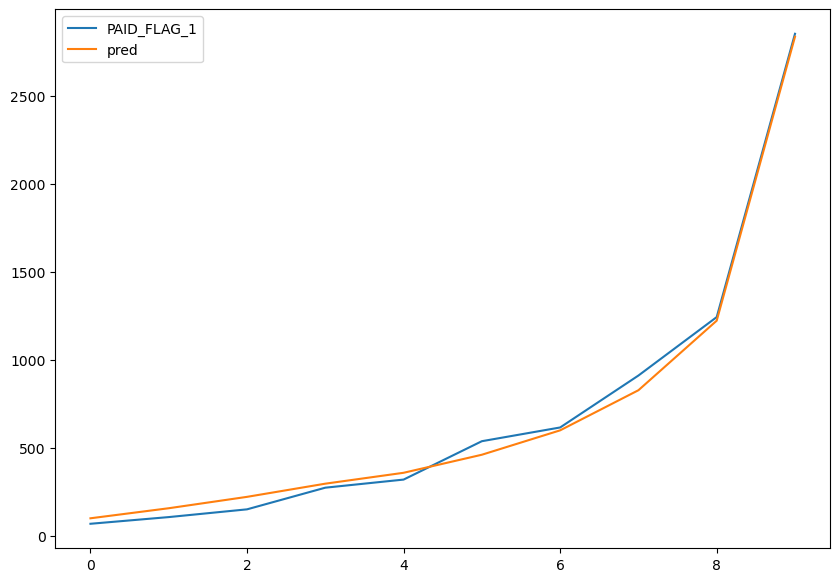

In [129]:
plt.figure(figsize=(10,7))
plt.plot(res['PAID_FLAG_1'], label='PAID_FLAG_1')
plt.plot(res['final_pred'], label='pred')
plt.legend()
plt.show()

## на train

In [110]:
X_train_norm = df_train.copy() 
grouped_df = X_train_norm.groupby(['HOLDING','PROGRAM_NAME','POLICY_NUMBER'])['pred'].sum().reset_index()
grouped_df = grouped_df.rename(columns={'pred': 'pred_norm'})
merged_df = pd.merge(X_train_norm, grouped_df, on=['HOLDING','PROGRAM_NAME', 'POLICY_NUMBER'])
merged_df['final_pred']=merged_df['pred']/merged_df['pred_norm']
merged_df['final_pred']=merged_df['final_pred'].round(6)

In [111]:
result = (
    merged_df.groupby(['PRICE_LEVEL'])[['final_pred', 'PAID_FLAG_1']]
    .sum()
    .sort_values('PAID_FLAG_1', ascending=False)
    .head(20)
)

print("PRICE_LEVEL по сумме PAID_FLAG_1 (по убыванию):")
print(result)

PRICE_LEVEL по сумме PAID_FLAG_1 (по убыванию):
               final_pred  PAID_FLAG_1
PRICE_LEVEL                           
Prochee       7960.876360         8032
STANDART      3691.761563         3882
BUSINESS      3738.323836         3678
ECONOM        2734.701436         2881
COMFORT       2091.185295         2220
VIP            518.279872          600
COMFORT_PLUS   195.769759          233
LUXE           222.338422          206
PREMIUM         23.395905           17
EXCLUSIVE       17.927213           12


In [121]:
result = (
    merged_df.groupby(['REGION ITOG'])[['final_pred', 'PAID_FLAG_1', 'pred']]
    .sum()
    .sort_values('PAID_FLAG_1', ascending=False)
    .head(20)
)

print("REGION ITOG_GROUP по сумме PAID_FLAG_1 (по убыванию):")
print(result)

REGION ITOG_GROUP по сумме PAID_FLAG_1 (по убыванию):
                  final_pred  PAID_FLAG_1         pred
REGION ITOG                                           
MOSKVA I MO      2423.533547         5833  2103.979164
SPB I LO         1086.801556         2569   977.575487
NOVOSIBIRSKAJa    458.299550         1261   392.708525
PERMSKIJ          518.719862          894   388.085651
TJuMENSKAJa       363.687770          838   284.974028
SVERDLOVSKAJa     364.932092          795   376.047323
OMSKAJa           346.257996          687   224.590713
NIZhEGORODSKAJa   351.037159          539   287.660296
VORONEZhSKAJa     316.635495          514   240.929817
KRASNODARSKIJ     271.972357          468   182.779190
PENZENSKAJa       193.818327          441   220.410807
ROSTOVSKAJa       293.713968          434   201.031479
ChELJaBINSKAJa    229.335019          416   210.246542
VLADIMIRSKAJa     198.270698          407   173.441606
SAMARSKAJa        133.410250          388   107.777660
KALUZhSKAJa

In [125]:
# Фильтр: только строки, где 'REGION ITOG' пустой
mask_null_region = merged_df['REGION ITOG'].isnull()

# Проверяем, есть ли такие строки
if mask_null_region.sum() == 0:
    print("Нет строк с пустым 'REGION ITOG'")
else:
    result_null = merged_df[mask_null_region][['final_pred', 'PAID_FLAG_1', 'pred']].sum()
    
    print("\nСуммы для строк с пустым 'REGION ITOG':")
    print(result_null)



Суммы для строк с пустым 'REGION ITOG':
final_pred     11165.541772
PAID_FLAG_1        0.000000
pred           12831.991807
dtype: float64


In [80]:
merged_df=merged_df[merged_df['REGION ITOG_GROUP']=='MOSKVA I MO']

In [119]:
merged_df[merged_df['GROUP (KOD SETI/LPU)']=="4976-Set'1589"]

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV,pred,pred_norm,final_pred
1989,4976-Set'1589,EVROMED (Omsk),008BS4581001544,MAJKUBEN-VEST,008BS4581001544,"OOO ""MAJKUBEN-VEST""",008BS4581001544-1,2022-11-27 00:00:00,2023-11-26 23:59:59,2022-11-27 00:00:00,...,False,True,False,0.00,0.0,0.0,0.00,0.282307,0.282307,1.000000
2960,4976-Set'1589,EVROMED (Omsk),008BS4581010025,EGIDA-55,008BS4581010025,"OOO ""EGIDA-55""",008BS4581010025-1,2025-02-07 00:00:00,2026-02-06 23:59:59,2025-02-07 00:00:00,...,False,True,False,0.00,0.0,0.0,0.00,0.282307,0.282307,1.000000
3571,4976-Set'1589,EVROMED (Omsk),008BS4581010066,OMSK SAJDING INVEST,008BS4581010066,"OOO ""OMSK SAJDING INVEST""",008BS4581010066-1,2025-02-09 00:00:00,2026-02-08 23:59:59,2025-02-09 00:00:00,...,False,True,False,0.00,0.0,0.0,0.00,0.282307,0.282307,1.000000
3572,4976-Set'1589,EVROMED (Omsk),008BS4581010066,OMSK SAJDING INVEST,008BS4581010066,"OOO ""OMSK SAJDING INVEST""",008BS4581010066-2,2025-02-09 00:00:00,2026-02-08 23:59:59,2025-02-09 00:00:00,...,False,True,False,0.00,0.0,0.0,0.00,0.282307,0.282307,1.000000
6954,4976-Set'1589,EVROMED (Omsk),008BS4581001401,SISTEMA,008BS4581001401,"OOO ""SISTEMA""",008BS4581001401-1,2022-12-12 00:00:00,2023-12-11 23:59:59,2022-12-12 00:00:00,...,False,True,False,0.00,0.0,0.0,0.00,0.282307,0.282307,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163428,4976-Set'1589,EVROMED (Omsk),008BS4581002054,SK SPETsENERGOSTROJ,008BS4581002054,"OOO SK ""SPETsENERGOSTROJ""",008BS4581002054-5,2023-01-06 00:00:00,2024-01-05 23:59:59,2023-01-06 00:00:00,...,False,True,False,0.00,0.0,0.0,0.00,0.282307,0.282307,1.000000
163429,4976-Set'1589,EVROMED (Omsk),008BS4581006873,STARGOROD-AGRO,008BS4581006873,"OOO ""STARGOROD-AGRO""",008BS4581006873-4,2024-02-02 00:00:00,2025-02-01 23:59:59,2024-02-02 00:00:00,...,False,False,True,0.73,1.0,1.0,0.04,0.336523,0.336523,1.000000
163430,4976-Set'1589,EVROMED (Omsk),008BS4581006873,STARGOROD-AGRO,008BS4581006873,"OOO ""STARGOROD-AGRO""",008BS4581006873-1,2024-02-02 00:00:00,2025-02-01 23:59:59,2024-02-02 00:00:00,...,False,False,True,0.73,1.0,1.0,0.04,0.336523,0.336523,1.000000
163431,4976-Set'1589,EVROMED (Omsk),008BS4581006873,STARGOROD-AGRO,008BS4581006873,"OOO ""STARGOROD-AGRO""",008BS4581006873-5,2024-02-02 00:00:00,2025-02-01 23:59:59,2024-02-02 00:00:00,...,False,False,True,0.73,1.0,1.0,0.04,0.336523,0.336523,1.000000


In [118]:
result = (
    merged_df.groupby(['GROUP (KOD SETI/LPU)'])[['final_pred', 'PAID_FLAG_1', 'pred']]
    .sum()
    .sort_values('PAID_FLAG_1', ascending=False)
    .head(20)
)

print("Топ-10 GROUP (KOD SETI/LPU) по сумме PAID_FLAG_1 (по убыванию):")
print(result)

Топ-10 GROUP (KOD SETI/LPU) по сумме PAID_FLAG_1 (по убыванию):
                      final_pred  PAID_FLAG_1        pred
GROUP (KOD SETI/LPU)                                     
771-KPP               650.224791          722  843.044731
4976-Set'1589         203.334156          487  120.416060
1721-Set'1            250.106355          395  249.487779
2184-set'1            263.787382          386  255.219744
773-set'1             184.109368          344  146.702536
59-105-04             149.715791          289  106.335018
643-1                 113.203443          230  138.981050
RMS001500             173.108997          220  119.139784
731-Set'1             176.818661          209  158.465100
1054-set'1            124.669183          208  124.826974
74-283-01             133.493904          204  128.857729
3322-Set'1             95.167587          158   63.737036
4976-Set'1322         108.469179          149   80.716968
4644-1                 83.398979          148   85.951601
4976-Set

In [130]:
# 1. Копируем данные
X_full_norm = X_full.copy()

# 2. Сразу обнуляем pred, где GROUP (KOD SETI/LPU) пропущен
X_full_norm.loc[X_full_norm['GROUP (KOD SETI/LPU)'].isnull(), 'pred'] = 0.0

# 3. Группируем — теперь pred_norm учитывает обнуление
grouped_df = X_full_norm.groupby(['HOLDING','PROGRAM_NAME','POLICY_NUMBER'])['pred'].sum().reset_index()
grouped_df = grouped_df.rename(columns={'pred': 'pred_norm'})

# 4. Слияние
merged_df = pd.merge(X_full_norm, grouped_df, on=['HOLDING','PROGRAM_NAME', 'POLICY_NUMBER'])

# 5. Нормировка
# Защита от деления на 0
merged_df['pred_norm'] = merged_df['pred_norm'].replace(0, 1)  # чтобы не было inf

merged_df['final_pred'] = merged_df['pred'] / merged_df['pred_norm']
merged_df['final_pred'] = merged_df['final_pred'].round(6)

# 6. Опционально: снова обнулить, если исходный pred был 0 (на всякий случай)
# (хотя он и так будет 0, т.к. 0 / X = 0)
# Но можно явно:
# merged_df.loc[merged_df['pred'] == 0, 'final_pred'] = 0.0

In [131]:
print(sum(merged_df['PAID_FLAG_1']), sum(merged_df['final_pred']))

36251 77555.01081097787


In [132]:
correlation = merged_df['PAID_FLAG_1'].corr(merged_df['final_pred'])
print(f"Корреляция между PAID_FLAG_1 и final_pred: {correlation:.4f}")

Корреляция между PAID_FLAG_1 и final_pred: 0.3685


In [371]:
merged_df.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply,SHARE_PRICE_LPU_FROM_MAX_v,SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV,pred,pred_norm,final_pred
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.0,Stroitel'stvo,Razdel F,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,TVERSKAJa,PROCHEE,Prjamoj dogovor SBS,800.0,1.0,67FE2FFA-09A5-5D7F-E053-596510AC686B,2.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0,1,0.14,0.5,0.96,level_2 (others),level_2 (others),14,level_1 (-1),44.0,5.0,0.10,0.69,False,True,True,False,0.0,0.0,0.0,0.0,0.291992,0.781465,0.373647
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,Zh,1,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,51,50-59,18-64,1.0,Stroitel'stvo,Razdel F,4.4,541.0,0.19,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,ECONOM,1.0,5793.0,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0,1,0.14,0.5,0.96,level_2 (others),level_2 (others),14,level_1 (-1),44.0,5.0,0.10,0.69,False,True,True,False,0.0,0.0,0.0,0.0,0.291992,0.781465,0.373647
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervichnyj,Tverskaja obl,Prochee,39,30-39,18-64,1.0,Stroitel'stvo,Razdel F,4.6,420.0,0.12,-1.0,0.0,0.0,0.0,1.0,None,None,not_def,0.0,0.0,None,0.0,Prochee,0.0,8433.0,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2.0,0.5,1,-1,0,1,0.14,0.5,1.00,level_2 (others),level_2 (others),14,level_1 (-1),82.0,16.0,0.18,1.00,False,True,True,False,0.0,0.0,0.0,0.0,0.489473,0.781465,0.626353
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-3,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1.0,Pervic

In [133]:
merged_df.shape

(717319, 96)

In [134]:
result = (
    merged_df.groupby(['GROUP (KOD SETI/LPU)'])[['final_pred', 'PAID_FLAG_1']]
    .sum()
    .sort_values('PAID_FLAG_1', ascending=False)
    .head(20)
)

print("Топ-10 GROUP (KOD SETI/LPU) по сумме PAID_FLAG_1 (по убыванию):")
print(result)


Топ-10 GROUP (KOD SETI/LPU) по сумме PAID_FLAG_1 (по убыванию):
                       final_pred  PAID_FLAG_1
GROUP (KOD SETI/LPU)                          
771-KPP               1976.119878         1462
4976-Set'1589          536.180005          669
773-set'1              680.444897          659
2184-set'1             797.103716          640
1721-Set'1            1166.447471          631
RMS001500              711.994625          472
59-105-04              460.641688          409
1054-set'1             402.715026          342
74-283-01              481.568619          341
731-Set'1              741.828317          340
54-Set'1               402.311727          277
643-1                  414.512127          268
3322-Set'1             483.644809          268
4976-Set'1322          305.089738          265
76-105-10              293.440413          247
1078-set'1             344.802707          244
4976-Set'1163          369.602473          219
4976-Set'1017          320.163607          

In [135]:
result = (
    merged_df.groupby(['PRICE_LEVEL'])[['final_pred', 'PAID_FLAG_1']]
    .sum()
    .sort_values('PAID_FLAG_1', ascending=False)
    .head(20)
)

print("Топ-10 GROUP (KOD SETI/LPU) по сумме PAID_FLAG_1 (по убыванию):")
print(result)


Топ-10 GROUP (KOD SETI/LPU) по сумме PAID_FLAG_1 (по убыванию):
                final_pred  PAID_FLAG_1
PRICE_LEVEL                            
Prochee       26688.401826        13505
BUSINESS      12770.107754         6241
STANDART      14442.816800         6167
ECONOM        11006.589206         4553
COMFORT        7575.698924         3850
VIP            1743.950086         1017
COMFORT_PLUS    651.246537          467
LUXE            552.519277          359
EXCLUSIVE        57.805038           38
PREMIUM          61.967903           34
None           2003.907460           20


In [136]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(merged_df['PAID_FLAG_1'], merged_df['final_pred'])
gini = 2 * auc - 1

print(f"Gini (по всем обращениям): {gini:.4f}")

Gini (по всем обращениям): 0.6814


In [ ]:
# X_test_norm.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,PAID_FLAG_1,const,SHARE_STAR_FROM_MAX_BIN_level_1 (-1),SHARE_STAR_FROM_MAX_BIN_level_2 (others),SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_1 (-1),SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_2 (others),pred,pred_bins
247,771-Perm',Perm',008BS4580002034,SZ SK AL'FA,008BS4580002034,"OOO ""SPETsIALIZIROVANNYJ ZASTROJSchIK ""OMEGA-G...",008BS4580002034-1,17.12.23,16.12.24,17.12.23,...,1,1,False,True,False,True,True,False,0.396174,"(0.316, 0.997]"
256,773-set'1,Set' meditsinskih tsentrov Doktor ARBITAJLO,008BS4581005092,ENLIL',008BS4581005094,"OOO ""ENLIL'""",008BS4581005092-2,22.09.23,21.09.24,22.09.23,...,1,1,True,False,True,False,True,False,0.287363,"(0.265, 0.316]"
297,4976-Set'1322,SM-klinika (set' klinik),008BS4580002380,MOSKOVSKIJ GOSUDARSTVENNYJ INSTITUT KUL'TURY,008BS4580002380,UFK PO MOSKOVSKOJ OBLASTI (MOSKOVSKIJ GOSUDARS...,008BS4580002380-6,26.03.24,25.03.25,26.03.24,...,0,1,False,True,True,False,False,True,0.243471,"(0.194, 0.265]"
298,731-Set'1,MedlajN-Servis,008BS4580002380,MOSKOVSKIJ GOSUDARSTVENNYJ INSTITUT KUL'TURY,008BS4580002380,UFK PO MOSKOVSKOJ OBLASTI (MOSKOVSKIJ GOSUDARS...,008BS4580002380-6,26.03.24,25.03.25,26.03.24,...,0,1,False,True,False,True,False,True,0.168116,"(0.119, 0.194]"
299,742/SSMTs / Dento El'/77-069-01,SSMTs / Dento El',008BS4580002380,MOSKOVSKIJ GOSUDARSTVENNYJ INSTITUT KUL'TURY,008BS4580002380,UFK PO MOSKOVSKOJ OBLASTI (MOSKOVSKIJ GOSUDARS...,008BS4580002380-6,26.03.24,25.03.25,26.03.24,...,1,1,False,True,False,True,False,True,0.268409,"(0.265, 0.316]"


In [ ]:
# X_test_norm = X_test_norm.drop(columns=['pred_bins'])

In [110]:
#X_train_norm.shape

In [ ]:
#X_train_norm.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,SHARE_STAR_FROM_MAX_v,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_STAR_FROM_MAX_BIN_level_1 (-1),SHARE_STAR_FROM_MAX_BIN_level_2 (others),SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_1 (-1),SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_2 (others),pred
0,2425-Set'1,Sechenovskij Universitet Moskva,008BS4581010418,"OOO ""VIKTORIJa TRANS""",NaN,"OOO ""VIKTORIJa TRANS""",008BS4581010418-1,24.03.25,23.03.26,24.03.25,...,-1.00,level_1 (-1),1,True,False,False,True,True,False,0.317362
1,1054-set'1,Semejnyj doktor,008BS4581010418,"OOO ""VIKTORIJa TRANS""",NaN,"OOO ""VIKTORIJa TRANS""",008BS4581010418-1,24.03.25,23.03.26,24.03.25,...,1.00,level_2 (others),4,False,True,True,False,False,True,0.341364
2,77-280-01,Lechebnyj tsentr,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,0.98,level_2 (others),8,False,True,False,True,False,True,0.336362
3,4976-Set'1292,AO «Semejnyj doktor»,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,0.96,level_2 (others),1,False,True,True,False,True,False,0.215946
4,771-KPP,KPP,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,1.00,level_2 (others),3,False,True,False,True,False,True,0.790203


In [ ]:
# import pandas as pd

# # Добавляем метку источника
# merged_df = merged_df.copy()  # хорошая практика
# merged_df_test = merged_df_test.copy()

# merged_df['dataset'] = 'train'
# merged_df_test['dataset'] = 'test'

# # Объединяем таблицы
# data_combined = pd.concat([merged_df, merged_df_test], ignore_index=True)

# # Проверка
# print("Размер объединённой таблицы:", data_combined.shape)
# print("Количество по датасетам:")
# print(data_combined['dataset'].value_counts())


Размер объединённой таблицы: (235902, 92)
Количество по датасетам:
dataset
train    185429
test      50473
Name: count, dtype: int64


In [114]:
# result = (
#     data_combined.groupby(['DOGOVOR_NUMBER_POLICY'])[['final_pred', 'PAID_FLAG_1']]
#     .sum()
#     .sort_values('PAID_FLAG_1', ascending=False)
#    # .head(20)
# )

# result.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\наложение_распределение_ЛПУ.xlsx')

In [ ]:
# data_combined.head(3)

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,SHARE_STAR_FROM_MAX_BIN_level_2 (others),SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_1 (-1),SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_2 (others),pred,pred_norm,final_pred,pred_bins,dataset
0,2425-Set'1,Sechenovskij Universitet Moskva,008BS4581010418,"OOO ""VIKTORIJa TRANS""",NaN,"OOO ""VIKTORIJa TRANS""",008BS4581010418-1,24.03.25,23.03.26,24.03.25,...,False,False,True,True,False,0.317362,0.658726,0.481782,"(0.324, 1.0]",train
1,1054-set'1,Semejnyj doktor,008BS4581010418,"OOO ""VIKTORIJa TRANS""",NaN,"OOO ""VIKTORIJa TRANS""",008BS4581010418-1,24.03.25,23.03.26,24.03.25,...,True,True,False,False,True,0.341364,0.658726,0.518218,"(0.324, 1.0]",train
2,77-280-01,Lechebnyj tsentr,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,True,False,True,False,True,0.336362,1.342511,0.250547,"(0.207, 0.324]",train


In [ ]:
# data_combined.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\распределение_ЛПУ1.xlsx', index=False )

In [ ]:
# df.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\распределение_ЛПУ_для_наложения_all.xlsx', index=False )

In [102]:
merged_df.columns.to_list()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'Region_itog',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGRAM_

In [137]:
merged_df.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\merged_df_v2.xlsx', index=False)

In [138]:
merged_df.shape


(717319, 96)

In [334]:
merged_df[merged_df['POLICY_NUMBER']=='008BS4580003016-59']

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply,SHARE_PRICE_LPU_FROM_MAX_v,SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV,pred,pred_norm,final_pred
717316,None,None,008BS4580003016,F5 GRUPP,008BS4580003015,"OOO ""EF5 SERVIS""",008BS4580003016-59,2024-11-28 00:00:00,2025-11-27 23:59:59,2025-10-01 00:00:00,2025-11-27 23:59:59,59,1,0,15,46,0.33,Zh,1,0,0,0,1,0,0,"Pushkino !VSE !Moskva i MO (Standart APP PND, ...",1.0,Pervichnyj,Novosibirskaja obl,Prochee,50,50-59,18-64,0.16,"Torgovlja optovaja i roznichnaja, remont avtot...",Razdel G,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,None,None,not_def,0.0,0.0,None,0.0,None,-1.0,-1.0,-1,Risk,30.0,noncovenant,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,3,-1.0,-1.0,5,-1,0,1,0.0,0.14,-1.0,level_1 (-1),level_1 (-1),14,level_1 (-1),2926.0,0.0,0.0,0.73,True,False,True,False,0.0,-0.0,-0.0,0.0,0.206136,0.206136,1.0


In [135]:
data_combined.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,SHARE_STAR_FROM_MAX_BIN_level_2 (others),SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_1 (-1),SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_2 (others),pred,pred_norm,final_pred,pred_bins,dataset
0,2425-Set'1,Sechenovskij Universitet Moskva,008BS4581010418,"OOO ""VIKTORIJa TRANS""",NaN,"OOO ""VIKTORIJa TRANS""",008BS4581010418-1,24.03.25,23.03.26,24.03.25,...,False,False,True,True,False,0.317362,0.658726,0.481782,"(0.324, 1.0]",train
1,1054-set'1,Semejnyj doktor,008BS4581010418,"OOO ""VIKTORIJa TRANS""",NaN,"OOO ""VIKTORIJa TRANS""",008BS4581010418-1,24.03.25,23.03.26,24.03.25,...,True,True,False,False,True,0.341364,0.658726,0.518218,"(0.324, 1.0]",train
2,77-280-01,Lechebnyj tsentr,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,True,False,True,False,True,0.336362,1.342511,0.250547,"(0.207, 0.324]",train
3,4976-Set'1292,AO «Semejnyj doktor»,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,True,True,False,True,False,0.215946,1.342511,0.160852,"(0.156, 0.207]",train
4,771-KPP,KPP,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,True,False,True,False,True,0.790203,1.342511,0.588600,"(0.324, 1.0]",train


In [ ]:
data_combined['SHARE_PRICE_LPU_FROM_MAX','SHARE_STAR_FROM_MAX','SHARE_MIN_SUBWAY_SYNT_FROM_MIN', 'SHARE_LPU_IN_PROGRAM','SHARE_SUBWAY_DIST_MIN_BINS_CODE','final_pred']

In [144]:
unique_table = data_combined[[
    'SHARE_PRICE_LPU_FROM_MAX',
    'SHARE_STAR_FROM_MAX',
    'SHARE_MIN_SUBWAY_SYNT_FROM_MIN',
    'SHARE_LPU_IN_PROGRAM',
    'SHARE_SUBWAY_DIST_MIN_BINS_CODE',
    'final_pred'
]].drop_duplicates().reset_index(drop=True)


unique_table.head(3)
unique_table.shape

(20615, 6)

In [153]:
import numpy as np

def concat_row(row):
    # Округляем до 2 знаков, если нужно, или оставляем как есть
    values = [
        f"{row['SHARE_PRICE_LPU_FROM_MAX']}",
        f"{row['SHARE_STAR_FROM_MAX']}",
        f"{row['SHARE_MIN_SUBWAY_SYNT_FROM_MIN']}",
        f"{row['SHARE_LPU_IN_PROGRAM']}",
        str(row['SHARE_SUBWAY_DIST_MIN_BINS_CODE'])  # категория — как есть
    ]
    return '_'.join(values)

unique_table['COMBO_KEY'] = unique_table.apply(concat_row, axis=1)

In [146]:
unique_table.head(3)


,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_LPU_IN_PROGRAM,SHARE_SUBWAY_DIST_MIN_BINS_CODE,final_pred,COMBO_KEY
0,1.0,-1.00,-1.00,0.50,1,0.481782,1.00_-1.00_-1.00_0.50_1.0
1,-1.0,1.00,0.46,0.50,4,0.518218,-1.00_1.00_0.46_0.50_4.0
2,1.0,0.98,0.47,0.33,8,0.250547,1.00_0.98_0.47_0.33_8.0


In [78]:
df_itog_for_nalozh=df

In [154]:
import numpy as np

def concat_row(row):
    # Округляем до 2 знаков, если нужно, или оставляем как есть
    values = [
        f"{row['SHARE_PRICE_LPU_FROM_MAX']}",
        f"{row['SHARE_STAR_FROM_MAX']}",
        f"{row['SHARE_MIN_SUBWAY_SYNT_FROM_MIN']}",
        f"{row['SHARE_LPU_IN_PROGRAM']}",
        str(row['SHARE_SUBWAY_DIST_MIN_BINS_CODE'])  # категория — как есть
    ]
    return '_'.join(values)

df_itog_for_nalozh['COMBO_KEY'] = df_itog_for_nalozh.apply(concat_row, axis=1)

In [141]:
df.head(3)

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_PRICE_LPU_BIN,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,PAID_FLAG_1,const,COMBO_KEY
0,2425-Set'1,Sechenovskij Universitet Moskva,008BS4581010418,"OOO ""VIKTORIJa TRANS""",NaN,"OOO ""VIKTORIJa TRANS""",008BS4581010418-1,24.03.25,23.03.26,24.03.25,...,0.50,-1.00,level_2 (others),level_1 (-1),level_1 (-1),1,level_1 (-1),1,1,1.00_-1.00_-1.00_0.50_1
1,1054-set'1,Semejnyj doktor,008BS4581010418,"OOO ""VIKTORIJa TRANS""",NaN,"OOO ""VIKTORIJa TRANS""",008BS4581010418-1,24.03.25,23.03.26,24.03.25,...,0.50,1.00,level_1 (-1),level_2 (others),level_2 (others),4,level_2 (others),0,1,-1.00_1.00_0.46_0.50_4
2,77-280-01,Lechebnyj tsentr,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,0.33,0.98,level_2 (others),level_2 (others),level_2 (others),8,level_2 (others),0,1,1.00_0.98_0.47_0.33_8


In [155]:
# Выбираем только нужные столбцы из data_combined
combo_pred = unique_table[['COMBO_KEY', 'final_pred']].drop_duplicates()

# Объединяем df с combo_pred по COMBO_KEY
df = df_itog_for_nalozh.merge(combo_pred, on='COMBO_KEY', how='left')

# Проверка: сколько значений подтянулось
print(f"Количество непустых final_pred после merge: {df['final_pred'].notnull().sum()}")
print(f"Общее количество строк в df: {len(df)}")


Количество непустых final_pred после merge: 25309058
Общее количество строк в df: 25309092


In [152]:
df.head(10)

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_PRICE_LPU_BIN,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,PAID_FLAG_1,COMBO_KEY,final_pred
0,2425-Set'1,Sechenovskij Universitet Moskva,008BS4581010418,"OOO ""VIKTORIJa TRANS""",NaN,"OOO ""VIKTORIJa TRANS""",008BS4581010418-1,24.03.25,23.03.26,24.03.25,...,0.50,-1.00,level_2 (others),level_1 (-1),level_1 (-1),1,level_1 (-1),1,1.00_-1.00_-1.00_0.50_1,NaN
1,1054-set'1,Semejnyj doktor,008BS4581010418,"OOO ""VIKTORIJa TRANS""",NaN,"OOO ""VIKTORIJa TRANS""",008BS4581010418-1,24.03.25,23.03.26,24.03.25,...,0.50,1.00,level_1 (-1),level_2 (others),level_2 (others),4,level_2 (others),0,-1.00_1.00_0.46_0.50_4,NaN
2,77-280-01,Lechebnyj tsentr,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,0.33,0.98,level_2 (others),level_2 (others),level_2 (others),8,level_2 (others),0,1.00_0.98_0.47_0.33_8,NaN
3,4976-Set'1292,AO «Semejnyj doktor»,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,0.33,0.96,level_1 (-1),level_2 (others),level_2 (others),1,level_1 (-1),1,-1.00_0.96_0.93_0.33_1,NaN
4,771-KPP,KPP,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-1,17.04.23,16.04.24,17.04.23,...,15.00,1.00,level_2 (others),level_2 (others),level_2 (others),3,level_2 (others),0,0.93_1.00_0.91_15.00_3,NaN
5,77-280-01,Lechebnyj tsentr,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-2,17.04.23,16.04.24,17.04.23,...,0.33,0.98,level_2 (others),level_2 (others),level_2 (others),8,level_2 (others),0,1.00_0.98_0.47_0.33_8,NaN
6,4976-Set'1292,AO «Semejnyj doktor»,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-2,17.04.23,16.04.24,17.04.23,...,0.33,0.96,level_1 (-1),level_2 (others),level_2 (others),1,level_1 (-1),0,-1.00_0.96_0.93_0.33_1,NaN
7,771-KPP,KPP,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-2,17.04.23,16.04.24,17.04.23,...,15.00,1.00,level_2 (others),level_2 (others),level_2 (others),3,level_2 (others),0,0.93_1.00_0.91_15.00_3,NaN
8,77-280-01,Lechebnyj tsentr,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-3,17.04.23,16.04.24,17.04.23,...,0.33,0.98,level_2 (others),level_2 (others),level_2 (others),8,level_2 (others),1,1.00_0.98_0.47_0.33_8,NaN
9,4976-Set'1292,AO «Semejnyj doktor»,008BS4581003037,MAHURU,008BS4581003037,"OOO ""MAHURU""",008BS4581003037-3,17.04.23,16.04.24,17.04.23,...,0.33,0.96,level_1 (-1),level_2 (others),level_2 (others),1,level_1 (-1),0,-1.00_0.96_0.93_0.33_1,NaN
